# Исследование стартапов

- Автор: Промыслова Екатерина
- Дата: 24.08.2025

## Введение

### Описание проекта

Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. Для этого необходимо провести исследование на исторических данных. В проекте проведена работа с данными о компаниях, объёмах и типах привлечённых инвестиций, а также с дополнительной статистикой по возвратам средств.

### Цели и задачи проекта
**Цель проекта** - Предобработать датасет и убедиться, что данные в нём не излишни соответствуют здравому смыслу, а также ответить на вопросы заказчика как о предобработке, так и о значении данных для бизнеса. Выполнить анализ на основе обработанных данных и получить выводы, на основе которых заказчик сможет принять решения, важные для выхода на инвестиционный рынок в сфере стартапов.

**Задачи проекта:**

* Познакомиться с данными, провести предобработку таким образом, чтобы не потерять важные для анализа данные и не исказить результаты исследований на их основе
* Идентифицировать столбцы, по которым можно объединять данные из разных таблиц
* Сделать выводы, можно ли доверять данным о сотрудниках стартапов и их образовании
* Разобраться, что означают покупки за 0 или за 1 доллар
* Определить средние цены в зависимости от категории стартапов и количества раундов финансирования перед его покупкой
* Рассчитать и отобразить численные показатели и динамику

### Содержимое проекта

* [Знакомство с данными: загрузка и первичная предобработка](#first-bullet)
* [Предобработка данных, предварительное исследование](#second-bullet)
* [Исследовательский анализ объединённых таблиц](#third-bullet)
* [Итоговый вывод и рекомендации](#fourth-bullet)


## Знакомство с данными: загрузка и первичная предобработка <a class="anchor" id="first-bullet"></a>

Названия файлов:
* acquisition.csv
* company_and_rounds.csv
* people.csv
* education.csv
* degrees.csv

Опциональные датасеты:
* fund.csv
* investment.csv

### 1.1. Вывод общей информации, исправление названия столбцов

- Загрузить все данные по проекту.
- Проверить названия столбцов.
- Вывести информацию, которая необходима для принятия решений о предобработке, для каждого из датасетов.

In [1]:
# Загрузим необходимые для работы библиотеки:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install phik

In [2]:
# Загрузим датасеты:
acquisition = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
company_and_rounds = pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
people = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')
education = pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
degrees = pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')

# Загрузим опциональные датасеты:
fund = pd.read_csv('https://code.s3.yandex.net/datasets/fund.csv')
investment = pd.read_csv('https://code.s3.yandex.net/datasets/investment.csv')

Библиотеки и датасеты загружены. Ознакомимся с информацией о каждом датасете и сделаем выводы о предоставленных данных

In [3]:
# Знакомство с датасетом acquisition:
acquisition.info()
acquisition.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01
5,11,227,228,NaN,7140000,2003-08-05
6,12,5,230,cash,0,2007-07-01
7,14,318,314,cash,0,2006-10-01
8,15,20,333,stock,1500000000,2002-07-08
9,16,342,341,cash,350000000,2007-08-01


Всего в датасете `acquisition` 9407 строк и 6 столбцов.

Датасет хранит информацию о сделках по покупке компаний другими компаниями: компания-покупатель, купленная компания, сумма сделки, дата сделки и способ расчета.

Заголовки столбцов понятны и соответствуют типу snake_case, поэтому переименовывать их не нужно.

In [4]:
# Знакомство с датасетом company_and_rounds:
company_and_rounds.info()
# Выгрузим первые 30 строк, чтобы получше ознакомиться с датасетом и сделать выводы о столбцас company id и company_ID
company_and_rounds.head(30)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217472 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id            52928 non-nul

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10000.0,MYWEBBO,network_hosting,operating,2008-07-26,NaN,mywebbo.com,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,10001.0,THE Movie Streamer,games_video,operating,2008-07-26,NaN,themoviestreamer.com,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,10002.0,Synergie Media,advertising,operating,2007-06-27,NaN,synergie-media.com,NaN,MAR,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,10003.0,Green Basti Ecosystems,cleantech,operating,2008-08-20,NaN,NaN,NaN,IND,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,100042.0,HostNine,NaN,operating,NaN,NaN,hostnine.com,Hostnine,NaN,0.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Датасет `company_and_rounds` содержит 217774 строки и 22 столбца и хранит в себе информацию о компаниях и раундах финансирования.

Похоже на то, что данный датасет является результатом объединения двух датасетов: первый содержал основную информацию о компаниях, а второй - о раундах финансирования, при этом датасеты были объединены при помощи полного присоединения (full join), о чем свидетельствует тот факт, что в каждом столбце присутствуют пропуски. Об этом говорит количество значений в столбцах: столбцы под номерами 0-12 относятся к первому датасету (информация о компаниях), т.к. почти во всех столбцах (за исключением столбца closed at, который сообщает о том, что компании, для которых есть дата закрытия, недействующие) количество записей превышает 53000, а столбцы под номерами 13-21 остносятся ко второму датасету (информация о раундах финансирования), т.к. количество записей почти одинкаовое не превышает 52928. **В дальнейшем, возможно, стоит разбить данный датасет на два и зачистить первый от дубликатов, т.к. в едином датасете получается очень много ненужных дубликатов и пропусков.**

Необходимо решить проблему с наименованиями столбцов `company ID` и `company id`: при переводе к стилю snake_case они станут индентичными, что нельзя допускать. `Company ID`  относится к бывшему (до объединения) датасету с информацией о компаниях, оставим его название без изменений. Столбец `company id` относится к данным про раунды финансирования, поэтому заменим его название на `funded company id` - так будет понятно, что речь идет о компаниях, получавших финансирование.

После преобразований переведем названия всех столбцов к стилю snake_case.

In [5]:
# Переименуем столбец company id в funded company id
# Обратим внимание на то, что в названиях других столбцов двойные пробелы
company_and_rounds = company_and_rounds.rename(columns={'company  id': 'funded  company  id'})

In [6]:
# Приводим названия всех столбцов к стилю snake_case:
# Обратим внимание на то, что в названиях столбцов двойные пробелы
company_and_rounds.columns = company_and_rounds.columns.str.lower().str.replace('  ','_')
# Подстраховка на случай, если есть еще пробелы в начале или конце названия:
company_and_rounds.columns = company_and_rounds.columns.str.lower().str.replace(' ','')

In [7]:
company_and_rounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   company_id           217472 non-null  float64
 1   name                 217472 non-null  object 
 2   category_code        143886 non-null  object 
 3   status               217472 non-null  object 
 4   founded_at           109956 non-null  object 
 5   closed_at            3449 non-null    object 
 6   domain               147159 non-null  object 
 7   network_username     95534 non-null   object 
 8   country_code         108607 non-null  object 
 9   investment_rounds    217472 non-null  float64
 10  funding_rounds       217472 non-null  float64
 11  funding_total        217472 non-null  float64
 12  milestones           217472 non-null  float64
 13  funding_round_id     52928 non-null   float64
 14  funded_company_id    52928 non-null   float64
 15  funded_at        

In [8]:
# Знакомство с датасетом people:
people.info()
people.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN
5,100002,Keith,Kurzendoerfer,NaN,NaN
6,100006,Courtney,Homer,81558.0,jobsbostontech
7,100009,Eddy,Badrina,NaN,NaN
8,100010,Michael,Dadashyan,NaN,fbroulette
9,100011,Jeff,Grell,NaN,NaN


Датасет `people` состоит из 226709 строк и 5 столбцов.

Датасет `people` содержит информацию о сотрудниках компаний, однако id компании, в которой работает сотрудник, отсутствует в более, чем 80% строк. Тем не менее, для 34,6 тыс. человек мы сможем определить компании, в которых они работают (но стоит проверить, совпадают ли для датастов значения id). 

Также в датасет содержит названия аккаунтов некоторых (38,9 тыс.) сотрудников в соцсетях. 

Названия столбцов записаны в стиле snake_case и четко отражают хранящуюся в них информацию, поэтому их переименовывать не придется. 

In [9]:
# Знакомство с датасетом education:
education.info()
education.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN
5,6,1017,Northeastern University,1988-01-01
6,7,6176,Rochester Institute of Technology,2002-01-01
7,8,5412,University of Cambridge,2002-01-01
8,9,1243,University of Oregon,1997-01-01
9,10,6265,University of Pennsylvania,1989-01-01


Датасет `education` состоит из 109610 строк и 4 столбцов.

Датасет `education` содержит информацию об образовании сотрудников, поэтому объединив данный датасет с `people` мы получим информацию об образовании почти половины сотрудников (однако уже с первых строк мы видим, что у части сотрудников может быть несколько обрзований). Сведения об образовании включают в себя название учебного заведения/заведений, в которых учились сотрудники, а также год выпуска. Однако информация о годе выпуска доступна всего для 58 тыс. человек: эти данные могли быть не найдены, или сотрудник не окончил обучение по каким-либо причинам.

Названия столбцов записаны в стиле snake_case и четко отражают хранящуюся в них информацию, поэтому их переименовывать не придется.

In [10]:
# Знакомство с датасетом degrees:
degrees.info()
degrees.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"
5,6,p:1017,BS,Computer Science
6,7,p:6176,BS,Computer Science
7,8,p:5412,MS,Politics
8,9,p:1243,BA,International Business & Marketing
9,10,p:6265,BS,Economics


Датасет education состоит из 109610 строк и 4 столбцов - строк ровно столько же, сколько и в таблице `education`.

Присоединив этот датасет к датасету `education` (по столбцам `person_id` и `object_id`) можно дополнить информацию об образовании сотрудников, но `object_id`, уникальный номер сотрудника, представлен в отличном от аналогичного столбца в датасете `education` виде: в ходе дальнейшего анализа будет необходимо удалить из айди первую часть `p:` для обсепечения возможности присоединения таблиц.

Названия столбцов записаны в стиле snake_case и четко отражают хранящуюся в них информацию, поэтому их переименовывать не придется.

In [11]:
# Знакомство с датасетом fund:
fund.info()
fund.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11652 entries, 0 to 11651
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  11652 non-null  int64 
 1   name                11650 non-null  object
 2   founded_at          4605 non-null   object
 3   domain              7362 non-null   object
 4   network_username    2149 non-null   object
 5   country_code        7053 non-null   object
 6   investment_rounds   11652 non-null  int64 
 7   invested_companies  11652 non-null  int64 
 8   milestones          11652 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 819.4+ KB


,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaN,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0
3,100,"Kapor Enterprises, Inc.",NaN,kei.com,NaN,USA,2,1,0
4,1000,Speed Ventures,NaN,NaN,NaN,NaN,0,0,1
5,10000,3x5 Special Opportunity Partners,NaN,NaN,NaN,NaN,4,4,0
6,10001,Salem Partners,1997-01-01,salempartners.com,NaN,USA,1,1,0
7,10002,3T Capital,NaN,3tcapital.com,NaN,FRA,3,3,0
8,10003,Merieux Developpement,2009-01-01,merieux-developpement.com,NaN,FRA,2,2,0
9,10004,Aquasourca,NaN,aquasourca.com,NaN,FRA,1,1,0


Датасет `fund` содержит 11652 строки и 9 солбцов.

Названия столбцов записаны в стиле snake_case и четко отражают хранящуюся в них информацию, поэтому их переименовывать не придется.

В датасете сохранено мало общей информации о фондах (дата основания, сайт, аккаунты в соцсетях, страна), но при этом собрана полная информация об их деятельности, что может быть полезно, например, для поиска наиболее надежных фондов. 

В этом датасете встречается столбец с названием `network_username` (`company_and_rounds` и `people`). В следующих шагах мы проверим, взаимосвязаны ли эти столбцы друг с другом.

In [12]:
# Знакомство с датасетом investment:
investment.info()
investment.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61403 entries, 0 to 61402
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                61403 non-null  int64
 1   funding_round_id  61403 non-null  int64
 2   company_id        61403 non-null  int64
 3   fund_id           61403 non-null  int64
dtypes: int64(4)
memory usage: 1.9 MB


,id,funding_round_id,company_id,fund_id
0,1,1,4,1
1,2,1,4,2
2,3,3,5,4
3,4,4,5,1
4,5,4,5,5
5,6,4,5,6
6,7,4,5,3181
7,8,5,7299,3
8,9,6,9,6
9,10,7,9,7


Датасет `investment` содержит 61403 строки и 4 столбца. Пропусков при этом нет! Датасет содержит информацию о раундах инвестирования, которая может быть полезна, если появится необходимость детально проверить информацию о раундах финансирования какой-либо компании, в т.ч. идентифицировать фонды.

Названия столбцов записаны в стиле snake_case и четко отражают хранящуюся в них информацию, поэтому их переименовывать не придется.

### Промежуточный вывод

В ходе знакомства с данными была произведена оценка объема предоставленных данных и содержимого столбцов, а также переименованы и приведены к единому стилю названия столбцов.

**Переименованные столбцы**:
* В датасете `company_and_rounds` столбец `company id` был переименован в столбец 'funded company id', и далее назвения всех стлбцов приведены к стилю snake_case.

**На что следует обратить внимание**:
* Датасет `company_and_rounds` похож на результат объединения двух отдельных датасетов с информацией про компании и финансирование, объединение при этом было произведено полное, это объясняет большое количество пропусков. В дальнейшем стоит рассмотреть необходимость разделение этого датасета обратно на два для повышения качества данных.
* Столбец `object_id` в датасете `degrees`индентичен столбцу `person_id` в датасете `education`, поэтому их можно будет объединить для получения более полной информации об образовании сотрудников. Однако уникальный номер сотрудника в датасете `degrees` представлен в другом виде: в ходе дальнейшего анализа будет необходимо удалить из айди первую часть `p:` для обсепечения возможности присоединения таблиц.
* Стоит проверить налчие взаимосвязи столбцов network_username (в датасетах`company_and_rounds`, `people` и `fund`). В следующих шагах мы проверим, взаимосвязаны ли эти столбцы друг с другом.

### Смена типов и анализ пропусков

- Обработать типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.
- Оценить полноту данных.

#### Датафрейм Acquisition

In [13]:
# Посмотрим, в каких столбцах датасета acquisition можно заменить типы данных:
acquisition.info()
acquisition.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


Произведем следующие замены типов данных:
* `term_code` - способы оплаты - их всего три (не считая пустых значений), заменим на тип `category`
* `price_amount` - сумма сделки - заменим на тип `float` на случай, если есть не целые значения
* `acquired_at` - дата, заменим на `datetime`

In [14]:
# Замена типа данных на категориальный:
acquisition['term_code'] = acquisition['term_code'].astype('category')

In [15]:
# Замена типа данных на числовой с плавающей точкой:
acquisition['price_amount'] = pd.to_numeric(acquisition['price_amount'], downcast='float', errors='coerce')

In [16]:
# Замена типа данных на дату
acquisition['acquired_at'] = pd.to_datetime(acquisition['acquired_at'])

In [17]:
# Проверка:
acquisition.info()
acquisition.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    9407 non-null   int64         
 1   acquiring_company_id  9407 non-null   int64         
 2   acquired_company_id   9407 non-null   int64         
 3   term_code             1831 non-null   category      
 4   price_amount          9407 non-null   float32       
 5   acquired_at           9378 non-null   datetime64[ns]
dtypes: category(1), datetime64[ns](1), float32(1), int64(3)
memory usage: 340.2 KB


,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000.0,2007-05-30
1,7,59,72,cash,60000000.0,2007-07-01
2,8,24,132,cash,280000000.0,2007-05-01
3,9,59,155,cash,100000000.0,2007-06-01
4,10,212,215,cash,25000000.0,2007-07-01


**Работа с дубликатами**

In [18]:
# Проверим на явные дубликаты: не обнаружено
acquisition.duplicated().value_counts()

False    9407
dtype: int64

In [19]:
# Проверим уникальность значений term_code: неявных дубликатов нет
acquisition['term_code'].unique()

[NaN, 'cash', 'stock', 'cash_and_stock']
Categories (3, object): ['cash', 'stock', 'cash_and_stock']

In [20]:
# Проверим на скрытые дубликаты: по столбцам acquiring_company_id, acquired_company_id, price_amount, acquired_at
# Дату сделки, сумму и способ расчета не включаем, т.к. одна компания не может купить другую несколько раз
acquisition[['acquiring_company_id', 'acquired_company_id']].duplicated().value_counts()

False    9382
True       25
dtype: int64

In [21]:
# Перед удалением отсортируем датасет по столбцам с пропусками так, чтобы все пропуски остались внизу (максимально сохраним имеющиеся данные)
acquisition = acquisition.sort_values(by=['term_code', 'acquired_at', 'price_amount'], ascending=[True, True, True], na_position='last')

In [22]:
# Выявлено 25 дубликатов. Удалим их.
acquisition = acquisition.drop_duplicates(subset=['acquiring_company_id', 'acquired_company_id'], keep='first', inplace=False)

acquisition.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9382 entries, 8126 to 669
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    9382 non-null   int64         
 1   acquiring_company_id  9382 non-null   int64         
 2   acquired_company_id   9382 non-null   int64         
 3   term_code             1828 non-null   category      
 4   price_amount          9382 non-null   float32       
 5   acquired_at           9353 non-null   datetime64[ns]
dtypes: category(1), datetime64[ns](1), float32(1), int64(3)
memory usage: 412.4 KB


В датасете acquisition выявлены и удалены 25 дубликатов.

**Проанализируем пропуски:**
* `term_code` - большое количество пропусков. Вероятно, информация о способе расчета при сделках редко публикуется, поэтому пропусков так много. При желании можно поставить заглушку `unknown`, но также можно и игнорировать данные пропуски - при анализе они не помешают, а сам столбец малоинформативен.
* `acquired_at` - 29 пропусков. Вероятно, это незавершенные сделки или ошибка в данных. Можно удалить строки с пропусками, но лучше не терять данные и оставить пропуски в таком виде.

#### Датафрейм companies_and_rounds

In [23]:
# Посмотрим, в каких столбцах датасета company_and_rounds можно заменить типы данных:
company_and_rounds.info()
company_and_rounds.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   company_id           217472 non-null  float64
 1   name                 217472 non-null  object 
 2   category_code        143886 non-null  object 
 3   status               217472 non-null  object 
 4   founded_at           109956 non-null  object 
 5   closed_at            3449 non-null    object 
 6   domain               147159 non-null  object 
 7   network_username     95534 non-null   object 
 8   country_code         108607 non-null  object 
 9   investment_rounds    217472 non-null  float64
 10  funding_rounds       217472 non-null  float64
 11  funding_total        217472 non-null  float64
 12  milestones           217472 non-null  float64
 13  funding_round_id     52928 non-null   float64
 14  funded_company_id    52928 non-null   float64
 15  funded_at        

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,funded_company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Произведем следующие замены типов данных:
* `company_id`, `funding_round_id`, `funded_company_id` - заменим тип на `integer`
* `category_code` - заменим на тип `category`
* `status` - заменим на тип `category`
* `founded_at` - дата, заменим на `datetime`
* `closed_at` - дата, заменим на `datetime`
* `country_code` - заменим на тип `category`
* `investment_rounds` - заменим на тип `integer`
* `funding_rounds` - заменим на тип `integer`
* `milestones` - заменим на тип `integer`
* `funded_at` - дата, заменим на `datetime`
* `funding_round_type` - заменим на тип `category`
* `participants` - заменим на тип `integer`
* `is_first_round` - заменим на тип `bool`
* `is_last_round` - заменим на тип `bool`

Для оставшихся столбцов тип данных указан корректно.

In [24]:
# Произведем замену типа данных на category:
company_and_rounds[['category_code', 'status', 'country_code', 'funding_round_type']] = company_and_rounds[['category_code', 'status', 'country_code', 'funding_round_type']].astype('category')

In [25]:
# Произведем замену типа данных на datetime:
company_and_rounds['founded_at'] = pd.to_datetime(company_and_rounds['founded_at'])
company_and_rounds['closed_at'] = pd.to_datetime(company_and_rounds['closed_at'])
company_and_rounds['funded_at'] = pd.to_datetime(company_and_rounds['funded_at'])

In [26]:
# Замена типа данных на целочисленный:
company_and_rounds['company_id'] = pd.to_numeric(company_and_rounds['company_id'], downcast='integer', errors='coerce')
company_and_rounds['funding_round_id'] = pd.to_numeric(company_and_rounds['funding_round_id'], downcast='integer', errors='coerce')
company_and_rounds['funded_company_id'] = pd.to_numeric(company_and_rounds['funded_company_id'], downcast='integer', errors='coerce')
company_and_rounds['investment_rounds'] = pd.to_numeric(company_and_rounds['investment_rounds'], downcast='integer', errors='coerce')
company_and_rounds['funding_rounds'] = pd.to_numeric(company_and_rounds['funding_rounds'], downcast='integer', errors='coerce')
company_and_rounds['milestones'] = pd.to_numeric(company_and_rounds['milestones'], downcast='integer', errors='coerce')
company_and_rounds['participants'] = pd.to_numeric(company_and_rounds['participants'], downcast='integer', errors='coerce')

In [27]:
# Замена типа данных на булевый:
company_and_rounds[['is_first_round', 'is_last_round']] = company_and_rounds[['is_first_round', 'is_last_round']].astype('bool')

In [28]:
# Проверка:
company_and_rounds.info()
company_and_rounds.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id           217472 non-null  float64       
 1   name                 217472 non-null  object        
 2   category_code        143886 non-null  category      
 3   status               217472 non-null  category      
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  category      
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,funded_company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,False,True
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,False,False
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,True,False
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True


**Проанализируем пропуски**

Сейчас об устранении пропусков говорить рановато, т.к. нам предстоит разбить этот датасет на два отдельных.
Однако уже сейчас можно увидеть столбцы, в которых пропуски, вероятнее всего, останутся:

* `category_code` - пропуски, вероятно, связаны с упущениями при сборе данных. Можно заминить их заглушкой "unknown", но можно и игнорировать их, потому что заполнить их нечем, а пропуски не помешают анализу.
* `founded_at` - пропуски также могут быть связаны с упущениями при сборе данных. Игнорируем эти пропуски, т.к. у столбца формат datetime.
* `closed_at` - столбец указывает на то, что компании, имеющие данные в этом столбце недействительны. Пропуски значают то, что компания действующая. Оставим эти пропуски.
* `domain` - пропуски связаны с упущениями при сборе данных или с отсутствием сайтов у компаний (характерно для стартапов на этапе идеи или бизнес-плана). Для наших задач этот столбце не понадобится, поэтому игнорируем пропуски.
* `network_username` - пропуски аналогично связаны с упущениями при сборе данных или с отсутствием профилей компаний в социальных сетях. Игнорируем пропуски, т.к. данный столбец нам не понадобится.
* `country code` - скорее всего, данные были упущены на этапе сбора данных. В теории можно дозаполнить пропуски вручную, но мы их игнорируем, т.к. для наших задач этот столбец не понадобится.
* `funded_at` - пропусков совсем немного, и эти данные не получится восстановить используя существующий набор данных. Чтобы не терять другую важую инфорацию, пропуски можно игнорировать.


Дубликаты пока не будем искать - сделаем это после разъединения таблиц.

##### Датафрейм people

In [29]:
# Посмотрим, в каких столбцах датасета people можно заменить типы данных:
people.info()
people.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


Произведем следующие замены типов данных: 
* `company_id` - заменим на `integer` 

In [30]:
# Замена типов данных на category:
people['company_id'] = pd.to_numeric(people['company_id'], downcast='integer', errors='coerce')

In [31]:
# Проверка:
people.info()
people.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


**Работа с дубликатами**

In [32]:
# Проверим на явные дубликаты: не обнаружены
people.duplicated().value_counts()

False    226709
dtype: int64

In [33]:
# Переведем данные network_username в нижний регистр
people['network_username'] = people['network_username'].str.lower()

In [34]:
# Проверим на неявные дубликаты: люди с одинаковыми именами и фамилиями, работающие в одной компании
# Люди с одинаковыми именами и фамилии, работающие в одной компании - большая редкость, поэтому считаем за дубликаты
people[['first_name', 'last_name','company_id']].duplicated().value_counts()
# Найдено 10403 дубликата

False    216306
True      10403
dtype: int64

In [35]:
# Отсортируем датасет, чтобы минимизировать потерю непустых значений 
people = people.sort_values(by=['company_id', 'network_username'], ascending=[True, True], na_position='last')

In [36]:
# Удалим найденные дубликаты:
people = people.drop_duplicates(subset=['first_name', 'last_name','company_id'], keep='first', inplace=False)

In [37]:
# Проверим на неявные дубликаты по имени, фамилии и нику в соцсетях:
people[['first_name', 'last_name','network_username']].duplicated().value_counts()
# Найдено 1650 дубликата

False    214656
True       1650
dtype: int64

In [38]:
# Удалим дубликаты:
people = people.drop_duplicates(subset=['first_name', 'last_name','network_username'], keep='first', inplace=False)

people.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 214656 entries, 3834 to 226704
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                214656 non-null  int64  
 1   first_name        214651 non-null  object 
 2   last_name         214655 non-null  object 
 3   company_id        34447 non-null   float64
 4   network_username  38445 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 9.8+ MB


Из датасета `people` удалено 12053 дубликатов (10403 + 1643).

**Проанализируем пропуски**
* `first_name` и `last_name` - эти пропуски можно дозаполнить вручную или заменить заглушкой `unknown`.
* `company_id` - невозможно без применения "ручного труда" заполнить данные о компаниях, в которых работают сотрудники. У проекта нет цели идентифицировать место работы каждого сотрудника, поэтому пропуски можно игнорировать.  
* `network_username` - найти и заполнить данные об аккаунтах сотрудников в соцсетях возможно только вручную (и нет гарантии, что удастся полностью их заполнить). У проекта нет цели идентифицировать аккаунт каждого сотрудника, поэтому пропуски можно игнорировать. 

#### Датафрейм education

In [39]:
# Посмотрим, в каких столбцах датасета education можно заменить типы данных:
education.info()
education.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


Произведем следующие замены типов данных:
* `graduated_at` - заменим на `datetime`

In [40]:
# Замена типа данных на datetime:
education['graduated_at'] = pd.to_datetime(education['graduated_at'])

In [41]:
# Проверка
education.info()
education.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            109610 non-null  int64         
 1   person_id     109610 non-null  int64         
 2   instituition  109555 non-null  object        
 3   graduated_at  58054 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 3.3+ MB


,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaT
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaT


**Работа с дубликатами**

In [42]:
# Проверка на явные дубликаты (не обнаружены)
education.duplicated().value_counts()

False    109610
dtype: int64

In [43]:
education['instituition'].unique()

array([nan, 'Washington University, St. Louis', 'Boston University', ...,
       'Auburn University, Auburn, Alabama',
       'Loyola University, New Orleans, Louisiana',
       'Rutgers University, Newark, New Jersey'], dtype=object)

In [44]:
# Проверка на неявные дубликаты
# Помним про то, что у одного человека может быть несколько образований, поэтому важно смотреть на дату окончания
# Так как метод drop_duplicates() игнорирует пустые значения, можно не переживать за утерю полезных данных
education[['person_id', 'graduated_at']].duplicated().value_counts()
# Найдено 20019 дубликатов

False    89591
True     20019
dtype: int64

In [45]:
# Сортировка датасета
education = education.sort_values(by=['instituition', 'graduated_at'], ascending=[True, True], na_position='last')
# Удаление дубликатов
education = education.drop_duplicates(subset=['person_id', 'graduated_at'], keep='first', inplace=False)

education.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 89591 entries, 20901 to 39240
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            89591 non-null  int64         
 1   person_id     89591 non-null  int64         
 2   instituition  89542 non-null  object        
 3   graduated_at  56167 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 3.4+ MB


Найдены и удалены 20019 дубликатов из датасета education. Пропусков в столбце `instituition` стало значително меньше относительно кол-ва сотрудников.

**Проанализируем пропуски**

Пропуски в данных об образовании сотрудников **не обязательно означают отсуствие у них образования** - вероятно, эти данные были упущены или изначально засекречены.
* `instituition` - невозможо заполить пропуски о месте обучения (пропусков мало). Можно заменить их заглушкой `unknown` или игнорировать - они  не помешают анализу.
* `graduated_at` - пропусков много, и их невозможно заполнить. Лучшим решением будет их игнорировать, т.к. у проекта нет цели анализа данных о годах выпуска сотрудников из учебных заведений.  

#### Датафрейм degrees

In [46]:
# Посмотрим, в каких столбцах датасета degrees можно заменить типы данных:
degrees.info()
degrees.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


Произведем следующие замены типов данных:
* `degree_type` - заменим на `category`

In [47]:
# Замена типа данных на category:
degrees['degree_type'] = degrees['degree_type'].astype('category')

In [48]:
# Проверка
degrees.info()
degrees.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   id           109610 non-null  int64   
 1   object_id    109610 non-null  object  
 2   degree_type  98392 non-null   category
 3   subject      81298 non-null   object  
dtypes: category(1), int64(1), object(2)
memory usage: 3.0+ MB


,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


**Работа с пропусками**

In [49]:
# Проверим датасет на явные дубликаты (не обнаружены)
degrees.duplicated().value_counts()

False    109610
dtype: int64

In [50]:
# Выведем все уникальные значения degree_type
degrees['degree_type'].unique()
# Уникальных значений слишком много, чтобы как-либо их унифицировать. Попробуем найти дубликаты без преобразований в этом столбце

['MBA', 'BA', 'MS', 'BCS', 'BS', ..., 'Master of Science in Telecommuni', 'Masters in Applied Finance', 'Master of Public Health', 'Master's of Music', 'bachelors']
Length: 7149
Categories (7148, object): ['MBA', 'BA', 'MS', 'BCS', ..., 'Masters in Applied Finance', 'Master of Public Health', 'Master's of Music', 'bachelors']

In [51]:
# Проверим датасет на неявные дуликаты по полям object_id, degree_type, subject
degrees[['object_id', 'degree_type', 'subject']].duplicated().value_counts()
# Обнаружено 1914 дубликатов

False    107696
True       1914
dtype: int64

In [52]:
# Выполним сортировку:
degrees = degrees.sort_values(by=['degree_type', 'subject'], ascending=[True, True], na_position='last')

# Удалим дубликаты:
degrees = degrees.drop_duplicates(subset=['object_id', 'degree_type', 'subject'], keep='first', inplace=False)

degrees.info()
degrees.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 107696 entries, 13590 to 109577
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   id           107696 non-null  int64   
 1   object_id    107696 non-null  object  
 2   degree_type  97707 non-null   category
 3   subject      80761 non-null   object  
dtypes: category(1), int64(1), object(2)
memory usage: 3.8+ MB


,id,object_id,degree_type,subject
13590,13591,p:95082,!st Class Honors,NaN
36924,36925,p:78334,"""Mini-MBA""",Stanford/AEA Executive Institute
32089,32090,p:76342,'A' Levels,NaN
32090,32091,p:76342,'O' Levels,NaN
45820,45821,p:201402,(2Years) UniversityLife,Computer.internet.IT.PC


В датасете `degrees` были обнаружены и удалены 1914 дубликатов.

**Проанализируем пропуски**
* Поля `degree_type` и `subject` содержат информацию о ступени образования сотрудника и научной области образования. Эти данные не потребуются для конкретного проекта, поэтому пропуски не критичны. Можно заменить их заглушкой `unknown` или оставить в неизменнном виде. 

#### Датафрейм fund

In [53]:
# Посмотрим, в каких столбцах датасета fund можно заменить типы данных:
fund.info()
fund.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11652 entries, 0 to 11651
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  11652 non-null  int64 
 1   name                11650 non-null  object
 2   founded_at          4605 non-null   object
 3   domain              7362 non-null   object
 4   network_username    2149 non-null   object
 5   country_code        7053 non-null   object
 6   investment_rounds   11652 non-null  int64 
 7   invested_companies  11652 non-null  int64 
 8   milestones          11652 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 819.4+ KB


,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaN,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0
3,100,"Kapor Enterprises, Inc.",NaN,kei.com,NaN,USA,2,1,0
4,1000,Speed Ventures,NaN,NaN,NaN,NaN,0,0,1


Произведем следующие замены типов данных:
* `founded_at` - заменим на `datetime`
* `country_code` - заменим на `category`

In [54]:
# Замена типа данных на category:
fund['country_code'] = fund['country_code'].astype('category')

In [55]:
fund['founded_at'] = pd.to_datetime(fund['founded_at'])

In [56]:
# Проверка
fund.info()
fund.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11652 entries, 0 to 11651
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  11652 non-null  int64         
 1   name                11650 non-null  object        
 2   founded_at          4605 non-null   datetime64[ns]
 3   domain              7362 non-null   object        
 4   network_username    2149 non-null   object        
 5   country_code        7053 non-null   category      
 6   investment_rounds   11652 non-null  int64         
 7   invested_companies  11652 non-null  int64         
 8   milestones          11652 non-null  int64         
dtypes: category(1), datetime64[ns](1), int64(4), object(3)
memory usage: 742.6+ KB


,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaT,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0
3,100,"Kapor Enterprises, Inc.",NaT,kei.com,NaN,USA,2,1,0
4,1000,Speed Ventures,NaT,NaN,NaN,NaN,0,0,1


**Работа с дубликатами**

In [57]:
# Проверим на явные дубликаты (не обнаружены):
fund.duplicated().value_counts()

False    11652
dtype: int64

In [58]:
# Переводим значения в единый регистр
fund['domain'] = fund['domain'].str.lower()
fund['network_username'] = fund['network_username'].str.lower()
fund['country_code'] = fund['country_code'].str.upper()

In [59]:
# Проверим на неявные дубликаты
fund[['name','domain','network_username','country_code']].duplicated().value_counts()

False    11649
True         3
dtype: int64

In [60]:
# Выполним сортировку:
fund = fund.sort_values(by=['founded_at', 'domain', 'network_username','country_code'], ascending=[True, True, True, True], na_position='last')
# Удалим дубликаты:
fund = fund.drop_duplicates(subset=['name','domain','network_username','country_code'], keep='first', inplace=False)

fund.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11649 entries, 8764 to 11646
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  11649 non-null  int64         
 1   name                11648 non-null  object        
 2   founded_at          4605 non-null   datetime64[ns]
 3   domain              7360 non-null   object        
 4   network_username    2148 non-null   object        
 5   country_code        7052 non-null   object        
 6   investment_rounds   11649 non-null  int64         
 7   invested_companies  11649 non-null  int64         
 8   milestones          11649 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 910.1+ KB


В датасете `fund` выявлены и удалены 3 дубликата.

**Проанализируем пропуски**
* `name` - эти пропуски можно заменить заглушкой `unknown` или удалить - их всего два, и они не повлияют на качество данных. Но перед удалением важно проверить строки с этими пропусками: если это крупные фонды, то лучше их не удалять.
* Остальные столбцы с пропусками содержат информацию о датах основания фонда, сайтах, аккаунтах в соцсетях, странах присутствия. Они могут понадобиться только для углубленного анализа репутации фондов, но в целом для этого достаточно информации о совершенных фондами финансированиях (эти данные полные).

#### Датасет investment

In [61]:
# Посмотрим, в каких столбцах датасета investment можно заменить типы данных:
investment.info()
investment.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61403 entries, 0 to 61402
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                61403 non-null  int64
 1   funding_round_id  61403 non-null  int64
 2   company_id        61403 non-null  int64
 3   fund_id           61403 non-null  int64
dtypes: int64(4)
memory usage: 1.9 MB


,id,funding_round_id,company_id,fund_id
0,1,1,4,1
1,2,1,4,2
2,3,3,5,4
3,4,4,5,1
4,5,4,5,5


Датасет `investment` полностью состоит из айди (ключей), которые можно присоединять к другим таблицам. Оставим для них тип `integer`.

**Работа с дубликатами**

In [62]:
# Проверим на явные дубликаты:
investment.duplicated().value_counts()

False    61403
dtype: int64

In [63]:
# Проверим на неявные дубликаты:
investment[['funding_round_id','company_id','fund_id']].duplicated().value_counts()

False    61344
True        59
dtype: int64

In [64]:
# Удалим дубликаты:
investment = investment.drop_duplicates(subset=['funding_round_id','company_id','fund_id'], keep='first', inplace=False)

investment.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 61344 entries, 0 to 61402
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                61344 non-null  int64
 1   funding_round_id  61344 non-null  int64
 2   company_id        61344 non-null  int64
 3   fund_id           61344 non-null  int64
dtypes: int64(4)
memory usage: 2.3 MB


В датасете `investment` выявлены и удалены 59 дубликатов.

**Проанализируем пропуски**

Пропуски отсутствуют - данные полные!

### Промежуточный вывод

В ходе первичной предобработки были произведены замены типов данных:
* Определенные столбцы `object` были заменены на `category`
* В двух столбцах `company_and_rounds` значения с типом `int` были заменены на `bool`, т.к. значения 1 и 0 в них указывали на наличие или отсутствие определенных признаков.
* Были произведены попытки замены части данных типа `float` на `int` и наоборот, но не везде замена на данным этапе удалась, т.к. этому мешают пропуски.
* В целом пропусков, способных повлиять на качество анализа нет, но большой вопрос касаемо пропущенных значений остается для датасета `company_and_rounds`. В ходе детальной обработки датасета (разбивки его надвое) ожидаем, что критически важных пропусков удастся избежать.

Также были выявлены и удалены дубликаты, и в некоторых датасетах их количество оказалось впечатляющим:
* В датасете `acquisition`: 25
* В датасете `company_and_rounds`: удаление дубликатов не производилось - будет выполнено в следующей части проекта.
* В датасете `people`: 12053
* В датасете `education`: 20019
* В датасете `degrees`: 1914
* В датасете `fund`: 3
* В датасете `investment`: 59

Игнорирование дубликатов могло привести к значительному искажению итоговых результатов при исследовании, поэтому было принято решение удалить дубликаты в целях повышения качества данных.

## Предобработка данных, предварительное исследование <a class="anchor" id="second-bullet"></a>


### Раунды финансирования по годам

- Необходимо составить сводную таблицу по годам, в которой на основании столбца `raised_amount` для каждого года указан:
    - типичный размер средств, выделяемый в рамках одного раунда;
    - общее количество раундов финансирования за этот год.
    
- Оставить в таблице информацию только для тех лет, для которых есть информация о более чем 50 раундах финансирования.
- На основе получившейся таблицы построить график, который будет отражать динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

На основе полученных данных ответить на вопросы:

- В каком году типичный размер собранных в рамках одного раунда средств был максимален?
- Какая тенденция по количеству раундов и выделяемых в рамках каждого раунда средств наблюдалась в 2013 году?

In [65]:
# Создадим сводную таблицу:
funding_pivot = pd.pivot_table(
    company_and_rounds,
    index=company_and_rounds['funded_at'].dt.year,
    values='raised_amount',
    aggfunc={
        'raised_amount': [
            ('typical_funding_amt', 'median'),
            ('funding_rounds_cnt', 'count')
        ]
    }
)

# Отфильтруем по кол-ву раундов в году (>50):
filtered_funding_pivot = funding_pivot[funding_pivot['funding_rounds_cnt'] >= 50]
display(filtered_funding_pivot)

,funding_rounds_cnt,typical_funding_amt
funded_at,,
1999.0,76,2000000.0
2000.0,125,4200000.0
2001.0,96,3000000.0
2002.0,116,4200000.0
2003.0,159,3000000.0
2004.0,291,5000000.0
2005.0,1633,5500000.0
2006.0,2436,5000000.0
2007.0,3279,3973320.0


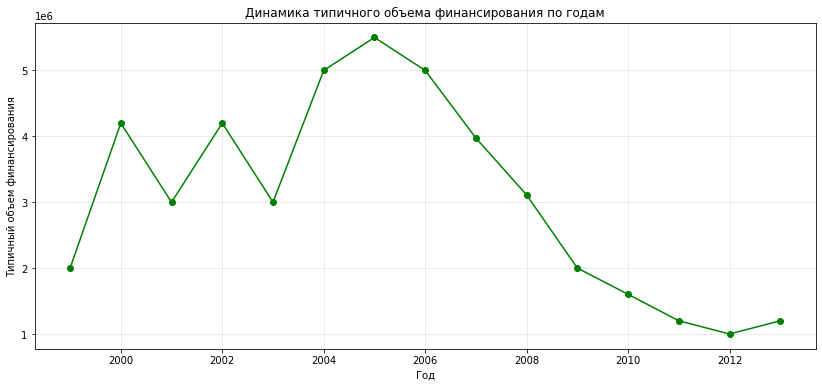

In [66]:
# Создадим график, отражающий изменение среднего размера инвестируемых средств по годам:
# Создаем график
plt.figure(figsize=(14, 6))

# Строим линейный график
plt.plot(filtered_funding_pivot.index, 
    filtered_funding_pivot['typical_funding_amt'], 
    marker='o',
    color='green')

# Настраиваем заголовок и подписи осей
plt.title('Динамика типичного объема финансирования по годам')
plt.xlabel('Год')
plt.ylabel('Типичный объем финансирования')
plt.grid(True, alpha=0.3)

**Ответ на первый вопрос: В каком году типичный размер собранных в рамках одного раунда средств был максимален?**

Максимальный типичный размер собранных средств в рамках одного раунда был 2005 году - 5 500 000 у.е.

Для ответа на второй вопрос построим новую сводную таблицу и новые графики:

In [67]:
# Создадим новый датасет с информацией только за 2013 год:
company_and_rounds_2013 = company_and_rounds[company_and_rounds['funded_at'].dt.year==2013]
funding_pivot_2013 = pd.pivot_table(
    company_and_rounds_2013,
    index=company_and_rounds['funded_at'].dt.month,
    values='raised_amount',
    aggfunc={
        'raised_amount': [
            ('typical_funding_amt', 'median'),
            ('funding_rounds_cnt', 'count')
        ]
    }
)

display(funding_pivot_2013)

,funding_rounds_cnt,typical_funding_amt
funded_at,,
1.0,1024,700000.0
2.0,740,1000000.0
3.0,865,750000.0
4.0,927,1100000.0
5.0,951,1037500.0
6.0,1039,1200000.0
7.0,1017,1500000.0
8.0,977,1000000.0
9.0,1064,1400000.0


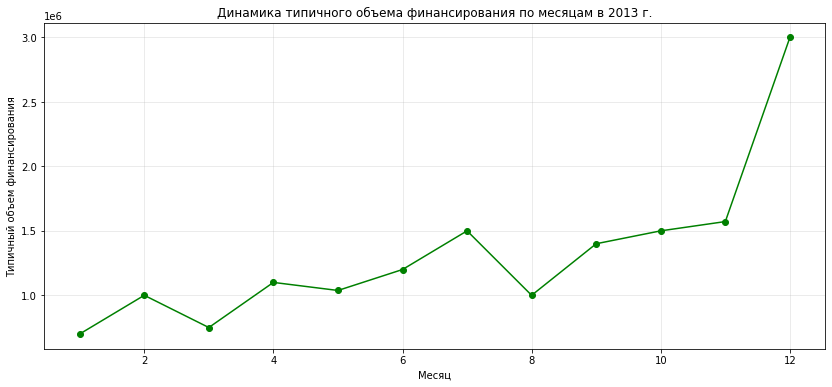

In [68]:
# Создадим график, отражающий изменение среднего размера инвестируемых средств в 2013 году:
# Создаем график
plt.figure(figsize=(14, 6))

# Строим линейный график
plt.plot(funding_pivot_2013.index, 
    funding_pivot_2013['typical_funding_amt'], 
    marker='o',
    color='green')

# Настраиваем заголовок и подписи осей
plt.title('Динамика типичного объема финансирования по месяцам в 2013 г.')
plt.xlabel('Месяц')
plt.ylabel('Типичный объем финансирования')
plt.grid(True, alpha=0.3)

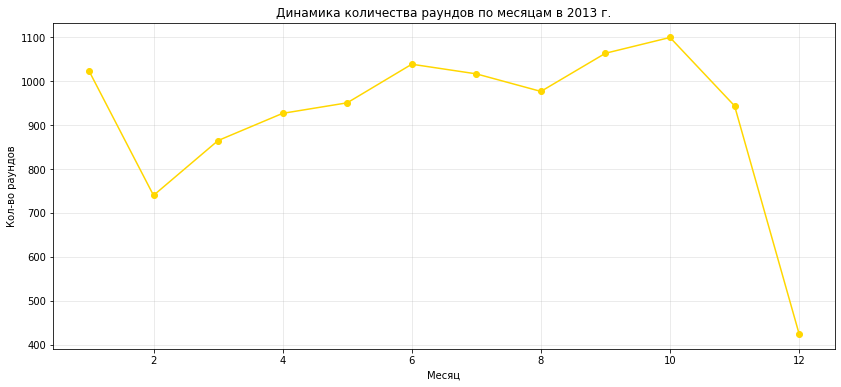

In [69]:
# Создадим график, отражающий изменение количества раундов в 2013 году:
# Создаем график
plt.figure(figsize=(14, 6))

# Строим линейный график
plt.plot(funding_pivot_2013.index, 
    funding_pivot_2013['funding_rounds_cnt'], 
    marker='o',
    color='gold')

# Настраиваем заголовок и подписи осей
plt.title('Динамика количества раундов по месяцам в 2013 г.')
plt.xlabel('Месяц')
plt.ylabel('Кол-во раундов')
plt.grid(True, alpha=0.3)

**Ответ на второй вопрос: Какая тенденция по количеству раундов и выделяемых в рамках каждого раунда средств наблюдалась в 2013 году?**

В целом на протяжении 2013 года активность инвесторов была рекордно высокой: количество раундов в месяц опускалось ниже отметки 900 шт. всего в трех меяцах: феврале, марте и декабре. Максимальное количество раундов было зафиксировано в октябре (1100 шт.), а минимальное - в декабре (424). Такое резкое снижение в декабре может быть связано с неполнотой данных (т.к. 2013 год - последний в общем датасете) или с сезонным снижением активности стартапов и инвесторов в предновогодний период.

При этом максимальный медианный размер финансирования в декабре оказался максимальным за весь 2013 год: 3 000 000 у.е., что в 2-3 раза выше значений в предыдущих месяцах (с января по ноябрь средний размер финансирования колебался между 700 000 у.е. и 1 571 950 у.е., демонстрируя плавный рост в течение года).


### Люди и их образование

Заказчик хочет понять, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний.

- Оценить, насколько информация об образовании сотрудников полна. Используя датасеты `people.csv` и `education.csv`, разделить все компании на несколько групп по количеству сотрудников и оцените среднюю долю сотрудников без информации об образовании в каждой из групп.
- Оценить, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу `degrees.csv`.

In [70]:
# Объединим датафреймы people и education:
people_education = pd.merge(people, education, how='left', left_on='id', right_on='person_id')

# Переименуем столбцы с одинаковыми названиями:
people_education = people_education.rename(columns={'id_x':'employee_id', 'id_y':'graduate_id'})

# Оставим сведения только об одном любом образовании сотрудников (для тех, у которых несколько дипломов)
people_education = people_education.drop_duplicates(subset=['employee_id'], keep='first', inplace=False)

people_education.head(20)

,employee_id,first_name,last_name,company_id,network_username,graduate_id,person_id,instituition,graduated_at
0,104800,Alex,Weinstein,1.0,alexweinstein,NaN,NaN,NaN,NaT
1,3,Kevin,Flaherty,1.0,NaN,707.0,3.0,Indiana University,NaT
2,9729,Bharath,Balasubramanian,2.0,spinfree,594.0,9729.0,Tamilnadu College of engineering,1998-01-01
3,4,Raju,Vegesna,3.0,NaN,NaN,NaN,NaN,NaT
4,5,Ian,Wenig,3.0,NaN,47871.0,5.0,McGill University,1986-01-01
6,6456,Sridhar,Vembu,3.0,NaN,43581.0,6456.0,"Indian Institute of Technology, Madras",1989-01-01
8,73699,Arsenio,Santos,4.0,arsenio,19351.0,73699.0,Columbia University,NaT
9,30923,Bob,Buch,4.0,bobbuch,58867.0,30923.0,"University of California, Hastings College of ...",NaT
10,7,Jay,Adelson,4.0,jayadelson,22649.0,7.0,Boston University,1992-01-01
11,88362,Mike,Cieri,4.0,mcieri,18835.0,88362.0,University of Chicago,2010-01-01


In [71]:
# Посчитаем кол-во сотрудников по компаниям и кол-во сотрудников со сведениями об образовании по компаниям
employees_education_info = people_education.groupby(['company_id']).agg(
    total_employees=('employee_id','count'),
    graduation_records=('graduated_at','count')
)

display(employees_education_info)

,total_employees,graduation_records
company_id,,
1.0,2,0
2.0,1,1
3.0,3,2
4.0,13,10
5.0,61,24
...,...,...
285897.0,2,1
285953.0,1,0
285972.0,2,0


Далее необходимо присвоить компаниям категории по размеру бизнеса: стандартная классификация нам не подойдет:

**Стандартная классификация:**

Микропредприятия: до 15 чел.

Малые предприятия: 15-100 чел.

Средние предприятия: 101-250 чел.

Крупные предприятия: 251+ чел.

**Посмотрим на описательную статистику нашего датасета и построим гистограмму, чтобы убедиться, чтобы определить оптимальные критерии классификации для данного кейса:**

In [72]:
employees_education_info.describe()

,total_employees,graduation_records
count,22829.000000,22829.000000
mean,1.508914,0.594726
std,2.767187,1.382898
min,1.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,0.000000
75%,1.000000,1.000000
max,244.000000,115.000000


<Axes: title={'center': 'График распределения количества сотрудников в компаниях'}, ylabel='Frequency'>

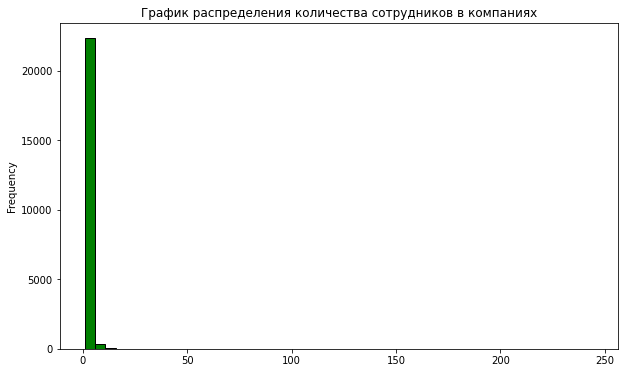

In [73]:
plt.figure(figsize=(10,6))

# Строим гистограмму
employees_education_info['total_employees'].plot(
    kind='hist',
    bins=50,
    title='График распределения количества сотрудников в компаниях',
    legend=False,
    rot=0,
    xlabel='Кол-во сотрудников в компании',
    ylabel='Частота',
    color='green',
    edgecolor='black'
)

Распределение крайне неравномерное: даже третий квартиль равен одноу, что говорит о том, что в большей части компаний всего по одному сотруднику (или же у нас есть сведения только об одном сотруднике для как минимум 75% компаний). Так как мы исследуем стартапы, это вполне может быть правдой.

**В таком случае сдвинем границы классификации в левую сторону:**

Микропредприятия: до 2 чел.

Малые предприятия: 3-5 чел.

Средние предприятия: 5-10 чел.

Крупные предприятия: 10+ чел.

In [74]:
# Добавим столбец с категориями предприятий по размеру:
employees_education_info['company_size'] = pd.cut(employees_education_info['total_employees'], bins=[0,2,5,10,250],
                            labels=["Микропредприятие", "Малое предприятие", "Среднее предприятие", "Крупное предприятие"], right=False)

# Выведем итоговую таблицу:
display(employees_education_info)

,total_employees,graduation_records,company_size
company_id,,,
1.0,2,0,Малое предприятие
2.0,1,1,Микропредприятие
3.0,3,2,Малое предприятие
4.0,13,10,Крупное предприятие
5.0,61,24,Крупное предприятие
...,...,...,...
285897.0,2,1,Малое предприятие
285953.0,1,0,Микропредприятие
285972.0,2,0,Малое предприятие


In [75]:
# Создадим таблицу, в которой суммируем кол-во сотрудников и сотрудников со сведениями об образованиями в разрезе размера компаний
company_size_employees = employees_education_info.groupby(['company_size']).agg(
    total_employees=('total_employees','sum'),
    graduation_records=('graduation_records','sum')
).sort_values(by='total_employees', ascending=False)

display(company_size_employees)

,total_employees,graduation_records
company_size,,
Микропредприятие,18057,7685
Малое предприятие,9929,3774
Среднее предприятие,3558,1081
Крупное предприятие,2903,1037


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Микропредприятие'),
  Text(1, 0, 'Малое предприятие'),
  Text(2, 0, 'Среднее предприятие'),
  Text(3, 0, 'Крупное предприятие')])

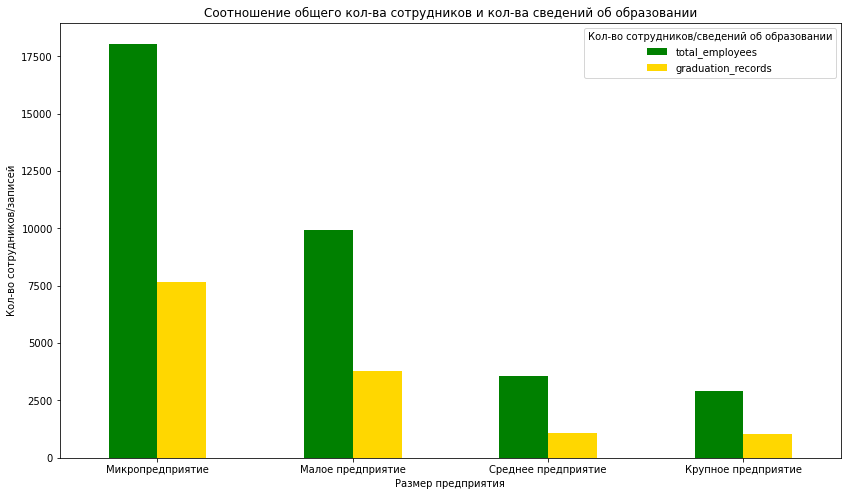

In [76]:
# Строим столбчатую диаграмму (используем группировку в абсолютных значениях для информативности),
# указываем цвета столбцов и размер диаграммы
company_size_employees.plot(kind='bar', color=['green','gold'], figsize=(14,8))

# Настраиваем график
plt.title('Соотношение общего кол-ва сотрудников и кол-ва сведений об образовании')
plt.ylabel('Кол-во сотрудников/записей')
plt.xlabel('Размер предприятия')
plt.legend(title='Кол-во сотрудников/сведений об образовании')
plt.xticks(rotation=0)

In [77]:
# Посчитаем доли имеющихся записей об образовании
company_size_employees['graduation_share'] = company_size_employees['graduation_records'] / company_size_employees['total_employees'] * 100

display(company_size_employees)

,total_employees,graduation_records,graduation_share
company_size,,,
Микропредприятие,18057,7685,42.559672
Малое предприятие,9929,3774,38.009870
Среднее предприятие,3558,1081,30.382237
Крупное предприятие,2903,1037,35.721667


**Вывод**:
    
В целом в полученнном датасете больше всего сотрудников микропредприятий (и, как следствие, доступных сведений об образовании сотрудников), т.к. наибольшая часть всех компаний в наших данных - микропредприятия (что логично, т.к. стартапы зачастую начинают с малых масштабов).

Так, в количественном значении, больше всего сведений об образовании сотрудников принадлежат микропредприятиям (7685), меньше всего - крупным предприятиям (1037).

В процентных  значениях по объему данных об образовании сотрудников лидируют микропредприятия (42,6%), на втором месте - малый бизнес (38%), замыкают тройку лидеров крупные компании (35,7%), и на последнем месте - средние предприятия (30,4%).

**Далее** ответим на вопрос, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу `degrees.csv`. Технически - да, т.к. датафрейм `degrees` можно присоединить к датасету education (по столбцам person_id и object_id).

Сделаем это и посмотрим, как эти данные можно использовать:

In [78]:
# Вспомним, как выглядит датасет degrees:
degrees.head()

,id,object_id,degree_type,subject
13590,13591,p:95082,!st Class Honors,NaN
36924,36925,p:78334,"""Mini-MBA""",Stanford/AEA Executive Institute
32089,32090,p:76342,'A' Levels,NaN
32090,32091,p:76342,'O' Levels,NaN
45820,45821,p:201402,(2Years) UniversityLife,Computer.internet.IT.PC


In [79]:
#Преобразуем тип столбца object_id в датафрейме degrees
degrees['object_id'] = degrees['object_id'].str.replace('p:','')
degrees['object_id'] = pd.to_numeric(degrees['object_id'], errors='coerce', downcast='integer')

In [80]:
# Первое объединение: people и eduacion
people_and_education = pd.merge(people, education, how='left', left_on='id', right_on='person_id')
# Переименуем столбцы с одинаковыми названиями:
people_and_education = people_education.rename(columns={'id_x':'employee_id', 'id_y':'graduate_id'})

# Второе объединение: 
people_education_degree = pd.merge(people_and_education, degrees, how='left', left_on='person_id', right_on='object_id')

people_education_degree.head(10)

,employee_id,first_name,last_name,company_id,network_username,graduate_id,person_id,instituition,graduated_at,id,object_id,degree_type,subject
0,104800,Alex,Weinstein,1.0,alexweinstein,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
1,3,Kevin,Flaherty,1.0,NaN,707.0,3.0,Indiana University,NaT,706.0,3.0,BBA,NaN
2,3,Kevin,Flaherty,1.0,NaN,707.0,3.0,Indiana University,NaT,707.0,3.0,MBA,NaN
3,9729,Bharath,Balasubramanian,2.0,spinfree,594.0,9729.0,Tamilnadu College of engineering,1998-01-01,594.0,9729.0,BS,Computer Science Engineering
4,4,Raju,Vegesna,3.0,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN
5,5,Ian,Wenig,3.0,NaN,47871.0,5.0,McGill University,1986-01-01,47871.0,5.0,BS,"Biology, Psychology"
6,5,Ian,Wenig,3.0,NaN,47871.0,5.0,McGill University,1986-01-01,47870.0,5.0,Degree,Advanced Business Professional Course
7,6456,Sridhar,Vembu,3.0,NaN,43581.0,6456.0,"Indian Institute of Technology, Madras",1989-01-01,43581.0,6456.0,BS,NaN
8,6456,Sridhar,Vembu,3.0,NaN,43581.0,6456.0,"Indian Institute of Technology, Madras",1989-01-01,43582.0,6456.0,PhD,Electrical Engineering
9,73699,Arsenio,Santos,4.0,arsenio,19351.0,73699.0,Columbia University,NaT,19351.0,73699.0,BS,"Music, Computer Science"


In [81]:
# Посчитаем кол-во сотрудников по компаниям и кол-во сотрудников со сведениями об ученых степенях
employees_degree_info = people_education_degree.groupby(['company_id']).agg(
    total_employees=('employee_id','count'),
    degree_records=('degree_type','count')
)

display(employees_degree_info)

,total_employees,degree_records
company_id,,
1.0,3,2
2.0,1,1
3.0,5,4
4.0,18,13
5.0,83,59
...,...,...
285897.0,2,1
285953.0,1,0
285972.0,2,0


In [82]:
# Добавим столбец с категориями предприятий по размеру:
employees_degree_info['company_size'] = pd.cut(employees_degree_info['total_employees'], bins=[0,2,5,10,250],
                            labels=["Микропредприятие", "Малое предприятие", "Среднее предприятие", "Крупное предприятие"], right=False)

In [83]:
# Группируем нужные данные по категориям размера компании
company_size_degree = employees_degree_info.groupby(['company_size']).agg(
    total_employees=('total_employees','sum'),
    degree_records=('degree_records','sum')
).sort_values(by='total_employees', ascending=False)

display(company_size_degree)

,total_employees,degree_records
company_size,,
Малое предприятие,17959,12438
Микропредприятие,14232,5130
Среднее предприятие,6413,3983
Крупное предприятие,5112,3436


(array([0, 1, 2, 3]),
 [Text(0, 0, 'Малое предприятие'),
  Text(1, 0, 'Микропредприятие'),
  Text(2, 0, 'Среднее предприятие'),
  Text(3, 0, 'Крупное предприятие')])

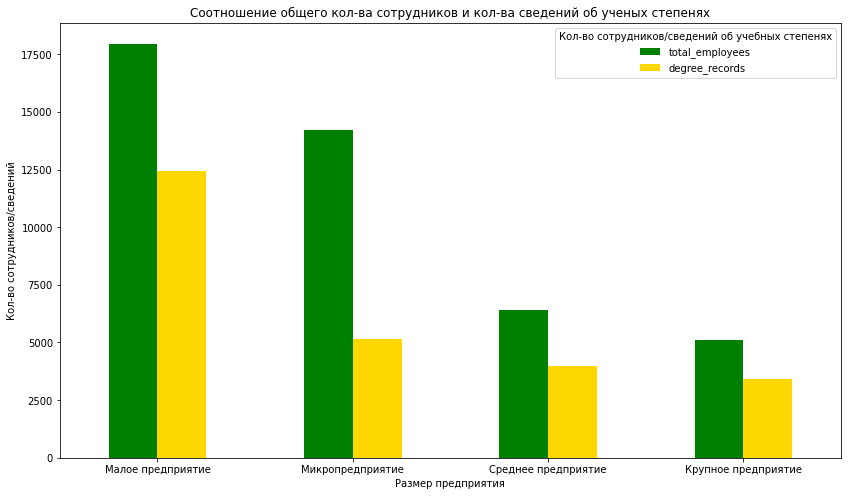

In [84]:
# Визуализируем при помощи столбчатой диаграммы
company_size_degree.plot(kind='bar', color=['green','gold'], figsize=(14,8))

# Настраиваем график
plt.title('Соотношение общего кол-ва сотрудников и кол-ва сведений об ученых степенях')
plt.ylabel('Кол-во сотрудников/сведений')
plt.xlabel('Размер предприятия')
plt.legend(title='Кол-во сотрудников/сведений об учебных степенях')
plt.xticks(rotation=0)

In [85]:
# Посмотрим на доли сотрудников со сведениями об ученых степенях
company_size_degree['degree_records_perc'] = company_size_degree['degree_records'] / company_size_degree['total_employees']

display(company_size_degree)

,total_employees,degree_records,degree_records_perc
company_size,,,
Малое предприятие,17959,12438,0.692578
Микропредприятие,14232,5130,0.360455
Среднее предприятие,6413,3983,0.621082
Крупное предприятие,5112,3436,0.672144


**Вывод:**

Датафрейм `degrees` возможно присоединить к датафреймам `people` и `education`. Также этот датафрейм содержит больше сведений об образовании сотрудников, чем датафрейм `education`. Важно отметить, что доли сотрудников с информацией об образовании очень сильно различаются при различных методах подсчета.

Также данные об ученых степенях могут быть полезны для ответов на более специфические запросы: например, посчитать кол-во сотрудников с MBA или изучить кол-во сотрудников, имеющих образование в конкретной сфере.  

In [86]:
# Пример использования данных о степенях образования: найдем кол-во сотрудников, имеющих разные ступени:
degrees_info = people_education_degree.groupby(['degree_type'])['employee_id'].count().sort_values(ascending=False)
display(degrees_info)
# Также можно сделать более сложные расчеты и посмотреть по размерам компаний количество сотрудников с разными научными степенями и пр. 

degree_type
BS                                  22362
BA                                  14662
MBA                                 14572
MS                                  11203
PhD                                  3908
                                    ...  
BSPH                                    0
Int. Diploma, Military Intellige        0
Ph.D., MS                               0
EMM Masters                             0
Honours B.Sc                            0
Name: employee_id, Length: 7148, dtype: int64

### 2.3. Объединять или не объединять — вот в чём вопрос

Некоторые названия столбцов встречаются в датасетах чаще других. В результате предварительной проверки датасетов было выяснено, что столбец `company_id` подходит для объединения данных.

- Необходимо установить, подходит ли для объединения данных столбец `network_username`, который встречается в нескольких датасетах. Нам необходимо понимать, дублируется ли для разных датасетов информация в столбцах с таким названием, и если да — то насколько часто.
- Оценить, можно ли использовать столбцы с именем `network_username` для объединения данных.

Столбцы с названием `username` используются в трех датафреймах:
* В датафрейме `company_and_rounds` столбец `network_username` хранит информацию о никах компаний в соцсетях
* В датафрейме `people` столбец `network_username` хранит информацию о никах сотрудников в соцсетях
* В датафрейме `funds` столбец `network_username` хранит информацию о никах фондов в соцсетях

Несмотря на то, что по идее данные столбцы должны хранить информацию о разных аккаунтах, не исключено, что эти данные могут пересекаться. Проверим это.

In [87]:
# Преобразуем столбцы network_username в множества и сразу удалим пустые значения:
companies_usernames = set(company_and_rounds['network_username'].dropna())
people_usernames = set(people['network_username'].dropna().unique())
funds_usernames =  set(fund['network_username'].dropna().unique())

In [88]:
# Найдем кол-во уникальных значений для всех network_usernames:
unique_companies_usernames = len(companies_usernames)
unique_people_usernames = len(people_usernames)
unique_funds_usernames = len(funds_usernames)

display(f'Кол-во уникальных значений ников компаний: {unique_companies_usernames}')
display(f'Кол-во уникальных значений ников сотрудников: {unique_people_usernames}')
display(f'Кол-во уникальных значений ников фондов: {unique_funds_usernames}')

'Кол-во уникальных значений ников компаний: 79571'

'Кол-во уникальных значений ников сотрудников: 38202'

'Кол-во уникальных значений ников фондов: 2091'

In [89]:
# Найдем количество пересечений никнеймов:
companies_people_intersections = len(companies_usernames & people_usernames)
companies_funds_intersections = len(companies_usernames & funds_usernames)
people_funds_intersections = len(people_usernames & funds_usernames)
total_intersections = len(companies_usernames & people_usernames & funds_usernames)

# Посчитаем пересечения в долях
companies_people_perc = round((companies_people_intersections / unique_companies_usernames *100), 2)
companies_funds_perc = round((companies_funds_intersections / unique_companies_usernames *100), 2)
people_funds_perc = round((people_funds_intersections / unique_people_usernames *100), 2)
total_perc = round((total_intersections / unique_companies_usernames *100), 2)

display(f'Кол-во дублирующихся никнеймов для компаний и сотрудников: {companies_people_intersections} ({companies_people_perc}%)')
display(f'Кол-во дублирующихся никнеймов для компаний и фондов: {companies_funds_intersections} ({companies_funds_perc}%)')
display(f'Кол-во дублирующихся никнеймов для компаний и сотрудников: {people_funds_intersections} ({people_funds_perc}%)')
display(f'Кол-во дублирующихся никнеймов для компаний и фондов: {total_intersections} ({total_perc}%)')

'Кол-во дублирующихся никнеймов для компаний и сотрудников: 1772 (2.23%)'

'Кол-во дублирующихся никнеймов для компаний и фондов: 45 (0.06%)'

'Кол-во дублирующихся никнеймов для компаний и сотрудников: 96 (0.25%)'

'Кол-во дублирующихся никнеймов для компаний и фондов: 9 (0.01%)'

**Вывод:**

Максимальное количество дублирующихся никнеймов обнаружено между никнеймами компаний и сотрудников - 2,76%. Пересечения для остальных столбцов составляет от 0,01% до 0,21, что ничтожно мало. Отсюда можно сделать вывод, что объединение данных на основе никнеймов бессмысленно из-за малого количества пересечений.


### Проблемный датасет и причина возникновения пропусков

Во время собственного анализа данных у заказчика больше всего вопросов возникло к датасету `company_and_rounds.csv`. В нём много пропусков как раз в информации о раундах, которая заказчику важна.

- Необходимо привести данные в вид, который позволит в дальнейшем проводить анализ в разрезе отдельных компаний. Обратите внимание на структуру датасета, порядок и названия столбцов, проанализируйте значения.

По гипотезе заказчика данные по компаниям из этой таблицы раньше хранились иначе, более удобным для исследования образом.

- Максимальным образом сохраняя данные, сохранив их связность и исключив возможные возникающие при этом ошибки, подготовить данные так, чтобы удобно было отобрать компании по параметрам и рассчитать показатели из расчёта на одну компанию без промежуточных агрегаций.

In [90]:
# Выведем на экран основную информацию о датасете:
company_and_rounds.info()
company_and_rounds.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id           217472 non-null  float64       
 1   name                 217472 non-null  object        
 2   category_code        143886 non-null  category      
 3   status               217472 non-null  category      
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  category      
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,funded_company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,False,True
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,False,False
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,True,False
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
5,10000.0,MYWEBBO,network_hosting,operating,2008-07-26,NaT,mywebbo.com,NaN,NaN,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
6,10001.0,THE Movie Streamer,games_video,operating,2008-07-26,NaT,themoviestreamer.com,NaN,NaN,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
7,10002.0,Synergie Media,advertising,operating,2007-06-27,NaT,synergie-media.com,NaN,MAR,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
8,10003.0,Green Basti Ecosystems,cleantech,operating,2008-08-20,NaT,NaN,NaN,IND,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
9,100042.0,HostNine,NaN,operating,NaT,NaT,hostnine.com,Hostnine,NaN,0.0,...,1.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True


Ранее я уже упоминала о том, что данный датасет, скорее всего, является результатом объединения двух датасетов: первый содержал основную информацию о компаниях, а второй - о раундах финансирования, при этом датасеты были объединены при помощи полного присоединения (full join), о чем свидетельствует тот факт, что в каждом столбце присутствуют пропуски. Об этом говорит количество значений в столбцах: столбцы под номерами 0-12 относятся к первому датасету (информация о компаниях), т.к. почти во всех столбцах (за исключением столбца closed at, который сообщает о том, что компании, для которых есть дата закрытия, недействующие) количество записей превышает 90000, а столбцы под номерами 13-21 остносятся ко второму датасету (информация о раундах финансирования), т.к. количество записей почти одинкаовое не превышает 52928. 

Попробуем рабить датасет на два (`companies` и `funding_rounds`) и зачистить их от пропусков и дубликатов.

In [91]:
# Формируем первый датасет - companies:
companies = company_and_rounds[['company_id','name','category_code','status','founded_at','closed_at','domain','network_username','country_code','investment_rounds','funding_rounds','funding_total','milestones']]
companies.info()
companies.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id         217472 non-null  float64       
 1   name               217472 non-null  object        
 2   category_code      143886 non-null  category      
 3   status             217472 non-null  category      
 4   founded_at         109956 non-null  datetime64[ns]
 5   closed_at          3449 non-null    datetime64[ns]
 6   domain             147159 non-null  object        
 7   network_username   95534 non-null   object        
 8   country_code       108607 non-null  category      
 9   investment_rounds  217472 non-null  float64       
 10  funding_rounds     217472 non-null  float64       
 11  funding_total      217472 non-null  float64       
 12  milestones         217472 non-null  float64       
dtypes: category(3), datetime64[ns](2), float64(5

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,0.0,0.0,4.0
5,10000.0,MYWEBBO,network_hosting,operating,2008-07-26,NaT,mywebbo.com,NaN,NaN,0.0,0.0,0.0,0.0
6,10001.0,THE Movie Streamer,games_video,operating,2008-07-26,NaT,themoviestreamer.com,NaN,NaN,0.0,0.0,0.0,0.0
7,10002.0,Synergie Media,advertising,operating,2007-06-27,NaT,synergie-media.com,NaN,MAR,0.0,0.0,0.0,0.0
8,10003.0,Green Basti Ecosystems,cleantech,operating,2008-08-20,NaT,NaN,NaN,IND,0.0,0.0,0.0,0.0
9,100042.0,HostNine,NaN,operating,NaT,NaT,hostnine.com,Hostnine,NaN,0.0,0.0,0.0,1.0


In [92]:
# Уберем явные дубликаты:
companies = companies.drop_duplicates()
companies.info()
# Кол-во строк сократилось с 217,8 тыс. до 196,6 тыс.

<class 'pandas.core.frame.DataFrame'>
Int64Index: 196554 entries, 0 to 217472
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id         196553 non-null  float64       
 1   name               196553 non-null  object        
 2   category_code      123186 non-null  category      
 3   status             196553 non-null  category      
 4   founded_at         91227 non-null   datetime64[ns]
 5   closed_at          2620 non-null    datetime64[ns]
 6   domain             126545 non-null  object        
 7   network_username   80591 non-null   object        
 8   country_code       87990 non-null   category      
 9   investment_rounds  196553 non-null  float64       
 10  funding_rounds     196553 non-null  float64       
 11  funding_total      196553 non-null  float64       
 12  milestones         196553 non-null  float64       
dtypes: category(3), datetime64[ns](2), float64(5

In [93]:
# Найдем строку c пропуском в столбце company_id
empty_company_id = companies[companies['company_id'].isna()]
display(empty_company_id)

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
217472,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
# Удалим эту строку, т.к. она полностью пустая
companies = companies.dropna(subset=['company_id'])

In [95]:
# Приведем к целочисленному типу строки, которые не удалось преобразовать ранее из-за пропусков:
companies['company_id'] = pd.to_numeric(companies['company_id'], downcast='integer', errors='coerce')
companies['investment_rounds'] = pd.to_numeric(companies['investment_rounds'], downcast='integer', errors='coerce')
companies['funding_rounds'] = pd.to_numeric(companies['funding_rounds'], downcast='integer', errors='coerce')
companies['milestones'] = pd.to_numeric(companies['milestones'], downcast='integer', errors='coerce')
# Проверка
companies.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 196553 entries, 0 to 217469
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id         196553 non-null  int32         
 1   name               196553 non-null  object        
 2   category_code      123186 non-null  category      
 3   status             196553 non-null  category      
 4   founded_at         91227 non-null   datetime64[ns]
 5   closed_at          2620 non-null    datetime64[ns]
 6   domain             126545 non-null  object        
 7   network_username   80591 non-null   object        
 8   country_code       87990 non-null   category      
 9   investment_rounds  196553 non-null  int16         
 10  funding_rounds     196553 non-null  int8          
 11  funding_total      196553 non-null  float64       
 12  milestones         196553 non-null  int8          
dtypes: category(3), datetime64[ns](2), float64(1

In [96]:
# Проанализируем пропуски:

companies.isna().sum() / companies.shape[0] * 100

company_id            0.000000
name                  0.000000
category_code        37.326828
status                0.000000
founded_at           53.586564
closed_at            98.667026
domain               35.617874
network_username     58.997828
country_code         55.233448
investment_rounds     0.000000
funding_rounds        0.000000
funding_total         0.000000
milestones            0.000000
dtype: float64

**Проанализируем пропуски:**
* `category_code` (37,3% пропусков) - пропуски, вероятно, связаны с упущениями при сборе данных. Можно заминить их заглушкой "unknown", но оставим пропуски, т.к. они не помешают анализу.
* `founded_at` (53,6% пропусков) - пропуски также могут быть связаны с упущениями при сборе данных. Игнорируем эти пропуски, т.к. у столбца формат datetime.
* `closed_at` (98,6% пропусков) - столбец указывает на то, что компании, имеющие данные в этом столбце недействительны. Пропуски значают то, что компания действующая. Оставим эти пропуски.
* `domain` (35,6% пропусков) - пропуски связаны с упущениями при сборе данных или с отсутствием сайтов у компаний (характерно для стартапов на этапе идеи или бизнес-плана). Для наших задач этот столбце не понадобится, поэтому игнорируем пропуски.
* `network_username` (59% пропусков) - пропуски аналогично связаны с упущениями при сборе данных или с отсутствием профилей компаний в социальных сетях. Игнорируем пропуски, т.к. данный столбец нам не понадобится.
* `country code` (55,2% пропусков) - скорее всего, данные были упущены на этапе сбора данных. В теории можно дозаполнить пропуски вручную, но мы их игнорируем, т.к. для наших задач этот столбец не понадобится.

In [97]:
# Формируем второй датасет - funding_rounds:
funding_rounds = company_and_rounds[['funding_round_id','funded_company_id','funded_at','funding_round_type','raised_amount','pre_money_valuation','participants','is_first_round','is_last_round']]
funding_rounds.info()
funding_rounds.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   funding_round_id     52928 non-null   float64       
 1   funded_company_id    52928 non-null   float64       
 2   funded_at            52680 non-null   datetime64[ns]
 3   funding_round_type   52928 non-null   category      
 4   raised_amount        52928 non-null   float64       
 5   pre_money_valuation  52928 non-null   float64       
 6   participants         52928 non-null   float64       
 7   is_first_round       217774 non-null  bool          
 8   is_last_round        217774 non-null  bool          
dtypes: bool(2), category(1), datetime64[ns](1), float64(5)
memory usage: 10.6 MB


,funding_round_id,funded_company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,False,True
1,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,False,False
2,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,True,False
3,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
4,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
5,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
6,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
7,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
8,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True
9,NaN,NaN,NaT,NaN,NaN,NaN,NaN,True,True


In [98]:
# Удалим пустые строки
funding_rounds = funding_rounds.dropna(subset=['funding_round_id'])
funding_rounds.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 52928 entries, 0 to 217773
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   funding_round_id     52928 non-null  float64       
 1   funded_company_id    52928 non-null  float64       
 2   funded_at            52680 non-null  datetime64[ns]
 3   funding_round_type   52928 non-null  category      
 4   raised_amount        52928 non-null  float64       
 5   pre_money_valuation  52928 non-null  float64       
 6   participants         52928 non-null  float64       
 7   is_first_round       52928 non-null  bool          
 8   is_last_round        52928 non-null  bool          
dtypes: bool(2), category(1), datetime64[ns](1), float64(5)
memory usage: 3.0 MB


In [99]:
# Проверим на явные дубликаты (их нет)
funding_rounds = funding_rounds.drop_duplicates()
funding_rounds.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 52928 entries, 0 to 217773
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   funding_round_id     52928 non-null  float64       
 1   funded_company_id    52928 non-null  float64       
 2   funded_at            52680 non-null  datetime64[ns]
 3   funding_round_type   52928 non-null  category      
 4   raised_amount        52928 non-null  float64       
 5   pre_money_valuation  52928 non-null  float64       
 6   participants         52928 non-null  float64       
 7   is_first_round       52928 non-null  bool          
 8   is_last_round        52928 non-null  bool          
dtypes: bool(2), category(1), datetime64[ns](1), float64(5)
memory usage: 3.0 MB


In [100]:
# Поменяем типы данных для айди на integer
funding_rounds['funding_round_id'] = pd.to_numeric(funding_rounds['funding_round_id'], downcast='integer', errors='coerce')
funding_rounds['funded_company_id'] = pd.to_numeric(funding_rounds['funding_round_id'], downcast='integer', errors='coerce')
funding_rounds.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 52928 entries, 0 to 217773
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   funding_round_id     52928 non-null  int32         
 1   funded_company_id    52928 non-null  int32         
 2   funded_at            52680 non-null  datetime64[ns]
 3   funding_round_type   52928 non-null  category      
 4   raised_amount        52928 non-null  float64       
 5   pre_money_valuation  52928 non-null  float64       
 6   participants         52928 non-null  float64       
 7   is_first_round       52928 non-null  bool          
 8   is_last_round        52928 non-null  bool          
dtypes: bool(2), category(1), datetime64[ns](1), float64(3), int32(2)
memory usage: 2.6 MB


**Проанализируем пропуски:**

В датасете `funding_rounds` пропуски содержатся только в одном столбце - `funded_at`. Данные пропуски могли возникнуть по трем причинам: ошибки при сборе информации, конфиденциальная информация о дате финансирования или это может сигнализировать о том, что финансирование не произошло. В любом случае, доля пропусков очень мала, поэтому игнорируем их.

**Вывод:**

Датасет `company_and_rounds` был разбит на два отдельных датасета: `companies` и `funding_rounds`. Таким образом, удалось избавиться от бессмысленных дубликатов и пропусков. Теперь можно использовать эти датасеты для анализа по отдельности, в зависимости от требований в задачах.


## Исследовательский анализ объединённых таблиц <a class="anchor" id="third-bullet"></a>


### Объединение данных

Объедините данные для ответа на вопросы заказчика, которые касаются интересующих его компаний. Заказчика прежде всего интересуют те компании, которые меняли или готовы менять владельцев. Получение инвестиций или финансирования, по мнению заказчика, означает интерес к покупке или продаже компании.

В качестве основы для объединённой таблицы возьмите данные из обработанного датасета `company_and_rounds.csv` — выберите только те компании, у которых указаны значения `funding_rounds` или `investment_rounds` больше нуля, или те, у которых в колонке `status` указано `acquired`. В результирующей таблице должно получиться порядка 40 тысяч компаний.

Проверьте полноту и корректность получившейся таблицы. Далее работайте только с этими данными.

In [101]:
# Отберем из датасета companies компании, соответствующие целевым критериям:
target_companies = companies[(companies['funding_rounds'] > 0) | (companies['investment_rounds'] > 0) | (companies['status'] == 'acquired')]

# Проверка6:
target_companies.info()
target_companies.head(20)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40747 entries, 0 to 217469
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   company_id         40747 non-null  int32         
 1   name               40747 non-null  object        
 2   category_code      35315 non-null  category      
 3   status             40747 non-null  category      
 4   founded_at         27807 non-null  datetime64[ns]
 5   closed_at          2128 non-null   datetime64[ns]
 6   domain             35754 non-null  object        
 7   network_username   20850 non-null  object        
 8   country_code       34742 non-null  category      
 9   investment_rounds  40747 non-null  int16         
 10  funding_rounds     40747 non-null  int8          
 11  funding_total      40747 non-null  float64       
 12  milestones         40747 non-null  int8          
dtypes: category(3), datetime64[ns](2), float64(1), int16(1), int

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000.0,5
3,10,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0,0,0.0,0
4,100,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0,0,0.0,4
15,1001,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0,1,5000000.0,3
20,10014,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0,1,0.0,4
21,10015,Fitbit,health,operating,2007-10-01,NaT,fitbit.com,fitbit,USA,0,5,68069200.0,0
26,100155,MTPV,cleantech,operating,2003-01-01,NaT,mtpv.com,NaN,USA,0,3,10125300.0,1
32,10018,Demandbase,analytics,operating,2006-01-01,NaT,demandbase.com,Demandbase,USA,0,3,33000000.0,3
36,100189,Locatrix Communications,mobile,operating,2003-11-01,NaT,locatrix.com,NaN,AUS,0,1,250000.0,1
37,10020,Threebrix E-services Pvt Ltd,NaN,operating,NaT,NaT,NaN,NaN,NaN,1,0,0.0,0


**Вывод:**

Интересующие компании успешно отобраны.


### Анализ выбросов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

In [102]:
# Создадим дополнительный столбец для отображения общего объема финансирования в миллионах у.е.
target_companies['funding_total_m'] = target_companies['funding_total'] / 1000000
target_companies.head()

<ipython-input-102-953159dbb39b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_companies['funding_total_m'] = target_companies['funding_total'] / 1000000


,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,funding_total_m
0,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,3,39750000.0,5,39.75
3,10,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0,0,0.0,0,0.00
4,100,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0,0,0.0,4,0.00
15,1001,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0,1,5000000.0,3,5.00
20,10014,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0,1,0.0,4,0.00


In [103]:
# Выведем описательную статистику по общим объемам финансирования:
target_companies['funding_total_m'].describe()

count    40747.00000
mean        10.13561
std         56.46436
min          0.00000
25%          0.00000
50%          0.60000
75%          5.65065
max       5700.00000
Name: funding_total_m, dtype: float64

In [104]:
# Исключим нулевые значения из выборки:
target_companies_nonzero = target_companies[target_companies['funding_total'] > 0]

In [105]:
target_companies_nonzero['funding_total_m'].describe()

count    27874.000000
mean        14.816520
std         67.759363
min          0.000291
25%          0.500000
50%          2.564500
75%         11.000000
max       5700.000000
Name: funding_total_m, dtype: float64

In [106]:
# Дополнительно выведем 95-й и 99-й перцентили:
percentiles = target_companies_nonzero['funding_total_m'].quantile([0.95, 0.99])
display(percentiles)

0.95     58.454435
0.99    175.087750
Name: funding_total_m, dtype: float64

<Axes: title={'center': 'График распределения объемов финансирования компаний'}, ylabel='Frequency'>

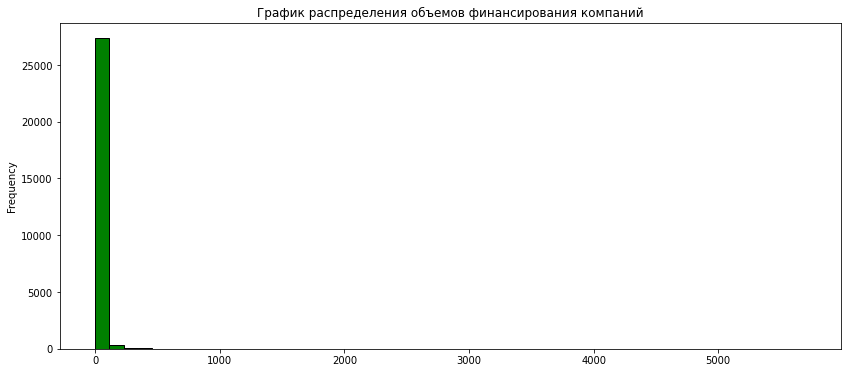

In [107]:
plt.figure(figsize=(14,6))

# Построим гистограмму:
target_companies_nonzero['funding_total_m'].plot(
    kind='hist',
    bins=50,
    title='График распределения объемов финансирования компаний',
    legend=False,
    rot=0,
    xlabel='Объем финансирования, млн. у.е.',
    ylabel='Частота',
    color='green',
    edgecolor='black'
)

Text(0, 0.5, 'Кол-во посадочных мест')

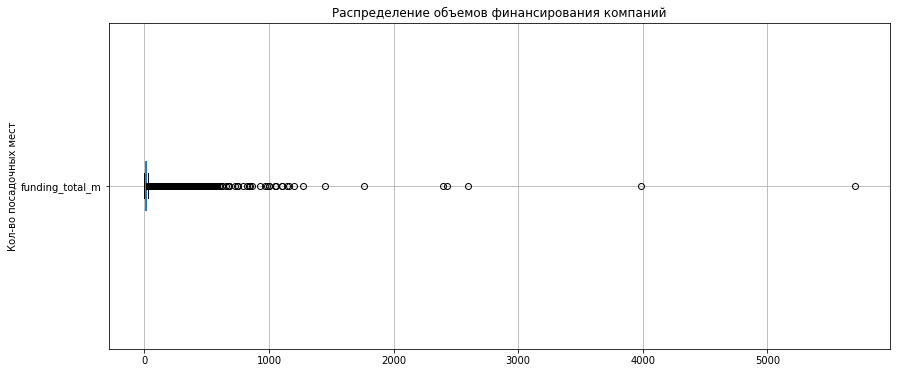

In [108]:
# Построим диаграмму размаха:
boxplot = target_companies_nonzero.boxplot(column='funding_total_m',
    vert=False,
    showfliers=True,
    figsize=(14,6))

boxplot.set_title('Распределение объемов финансирования компаний')
boxplot.set_ylabel('Кол-во посадочных мест')

Text(0, 0.5, 'Кол-во посадочных мест')

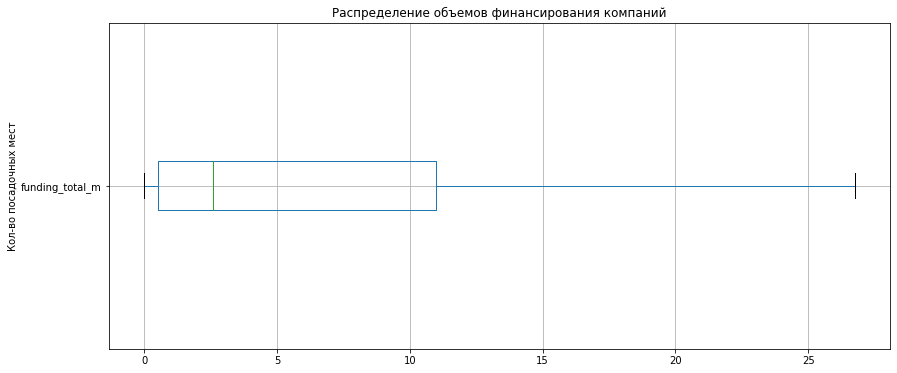

In [109]:
# Построим диаграмму размаха без выбросов:
boxplot = target_companies_nonzero.boxplot(column='funding_total_m',
    vert=False,
    showfliers=False,
    figsize=(14,6))

boxplot.set_title('Распределение объемов финансирования компаний')
boxplot.set_ylabel('Кол-во посадочных мест')

**Вывод:**

Распределение данных о размерах финансирования компаний имеет выраженную правостороннюю ассиметрию.

После исключения нулевых значений, минимальное значение - **291 у.е.**, а максимальное - **5,7 млрд. у.е.** Такие высокие значения не являются ошибкой - согласно источнику bloomberg.com, одним из самых дорогих стартапов является компания Uber, привлекшая 20 млрд. долларов за все время работы. 

Типичный размер общего финансирования (по медиане) - **2,56 млн. у.е.**, при этом третий квартиль равен **11 млн. у.е.**


Наиболее высокие значения (95-1 и 99-й перцентили) - **58,45 млн. у.е.** и **175,1 у.е.**

Обычные способы нахождения типичных значений к таким данным лучше не применять - типичные значения могут очень сильно зависеть от сферы стартапа, страны, года (для ретро данных) и прочих факторов.


### Куплены забесплатно?

- Исследовать компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.

In [110]:
# Вспоминаем информацию о датасетах, которые понадобятся для решения:
acquisition.info()
target_companies.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9382 entries, 8126 to 669
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    9382 non-null   int64         
 1   acquiring_company_id  9382 non-null   int64         
 2   acquired_company_id   9382 non-null   int64         
 3   term_code             1828 non-null   category      
 4   price_amount          9382 non-null   float32       
 5   acquired_at           9353 non-null   datetime64[ns]
dtypes: category(1), datetime64[ns](1), float32(1), int64(3)
memory usage: 412.4 KB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 40747 entries, 0 to 217469
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   company_id         40747 non-null  int32         
 1   name               40747 non-null  object        
 2   category_

In [111]:
# Объединяем датасеты
zero_deals=pd.merge(acquisition, target_companies, how='inner', left_on='acquired_company_id', right_on='company_id')

# Отфильтруем данные согласно требованиям:
zero_deals = zero_deals[(zero_deals['price_amount'] <= 1) & (zero_deals['funding_total'] != 0)]

zero_deals.info()
zero_deals.head(10)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1615 entries, 26 to 9362
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    1615 non-null   int64         
 1   acquiring_company_id  1615 non-null   int64         
 2   acquired_company_id   1615 non-null   int64         
 3   term_code             121 non-null    category      
 4   price_amount          1615 non-null   float32       
 5   acquired_at           1611 non-null   datetime64[ns]
 6   company_id            1615 non-null   int32         
 7   name                  1615 non-null   object        
 8   category_code         1550 non-null   category      
 9   status                1615 non-null   category      
 10  founded_at            1283 non-null   datetime64[ns]
 11  closed_at             13 non-null     datetime64[ns]
 12  domain                1543 non-null   object        
 13  network_username 

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,funding_total_m
26,9066,236079,266567,cash,0.0,2000-05-01,266567,WiiiWaaa,web,acquired,NaT,NaT,wiiiwaaa.com,wiiiwaaa,NaN,0,1,50000.0,1,0.05
169,503,4175,7440,cash,0.0,2006-06-27,7440,thePlatform,web,acquired,2000-01-01,NaT,theplatform.com,thePlatform,USA,0,1,8000000.0,4,8.00
179,681,350,1170,cash,0.0,2006-08-15,1170,CollegeHumor,games_video,acquired,1999-01-01,NaT,collegehumor.com,collegehumor,USA,0,1,20000000.0,0,20.00
186,14,318,314,cash,0.0,2006-10-01,314,Reddit,web,acquired,2005-01-01,NaT,reddit.com,reddit,USA,0,1,100000.0,3,0.10
190,470,29,559,cash,0.0,2006-11-16,559,Bix,web,acquired,NaT,NaT,bix.com,NaN,USA,0,1,6700000.0,3,6.70
259,926,1915,17879,cash,0.0,2007-05-21,17879,Modulus Video,NaN,acquired,1999-01-01,NaT,modulusvideo.com,site5,USA,0,1,8500000.0,1,8.50
286,65,146,698,cash,0.0,2007-08-01,698,Maya's Mom,web,acquired,NaT,NaT,mayasmom.com,NaN,USA,0,1,1000000.0,2,1.00
287,67,156,718,cash,0.0,2007-08-01,718,Glimpse,ecommerce,acquired,NaT,NaT,glimpse.com,NaN,USA,0,1,4000000.0,0,4.00
299,916,2680,17818,cash,0.0,2007-08-17,17818,Bridgestream,NaN,acquired,2000-01-01,NaT,bridgestream.com,NaN,USA,0,1,6500000.0,1,6.50
304,9121,415,997,NaN,0.0,2013-07-15,997,Zimbra,enterprise,acquired,2003-01-01,NaT,zimbra.com,zimbra,USA,0,1,14500000.0,3,14.50


In [112]:
# Проверим способы расчета для таких компаний
zero_deals['term_code'].unique()

['cash', NaN, 'cash_and_stock', 'stock']
Categories (3, object): ['cash', 'cash_and_stock', 'stock']

In [113]:
# Проверим страну происхождения таких компаний
zero_deals['country_code'].unique()

[NaN, 'USA', 'ISR', 'GBR', 'CAN', ..., 'KOR', 'HUN', 'CZE', 'FIN', 'UMI']
Length: 37
Categories (36, object): ['USA', 'ISR', 'GBR', 'CAN', ..., 'HUN', 'CZE', 'FIN', 'UMI']

In [114]:
# Проверим сферу деятельности таких компаний
zero_deals['category_code'].unique()

['web', 'games_video', NaN, 'ecommerce', 'enterprise', ..., 'fashion', 'design', 'automotive', 'transportation', 'photo_video']
Length: 37
Categories (36, object): ['web', 'games_video', 'ecommerce', 'enterprise', ..., 'design', 'automotive', 'transportation', 'photo_video']

Всего в датасете оказалось 1615 компаний, купленных за 0 или 1 долларов. На первый взгляд, ничего примечательного: такие компании встречаются в разных странах, сферы их деятельности разнообразны, и способы расчета по таким сделкам тоже разные.

После изучения информации о причинах продажи компаний за "бесценок" можно выделить следующие причины возникновение данного феномена:
* Юридическая формальность: в договоре при оформлении передачи прав собственности стоимость компании может быть записана как 0 или 1 доллар, при этом настоящая цена сделки может быть прописана в договоре отдельно в виде нескольких платежей.
* "Спасение" компании: при угозе банкротства компании собственник может продать компанию за символическую сумму лицу, заинтересованному в продолжении ведения этого бизнеса.
* Передача прав на интеллектуальную собственность: продажа юридического лица, которому принадлежат эти права за символическую сумму — эффективный способ их передачи.
* Реструктуризация (характерна для групп компаний): Продажа за доллар может означать передачу юрлица дочерней компании.
* Приостановка деятельности компании на территории определенной страны (характерно для крупных международных компаний): такие случаи были зафиксированы в России во время массового ухода компаний в 2022 г.

In [115]:
# Для расчета верхней и нижней границ выбросов используем метод межквартильного размаха:
# Первый и третий квартили:
Q1 = zero_deals['funding_total_m'].quantile(0.25) # использую столбец с объемом финансирования в млн. у.е.
Q3 = zero_deals['funding_total_m'].quantile(0.75)
display(f"Первый квартиль: {Q1}")
display(f"Третий квартиль: {Q3}")

# Межквартильный размах:
IQR = Q3 - Q1
display(f"Межквартильный размах: {IQR}")

# Рассчитаем границы выбросов
lower_bound = Q1 - 1.5 * IQR # Используем стандартный множитель - 1,5
upper_bound = Q3 + 1.5 * IQR

display(f"Нижняя граница выбросов: {lower_bound}")
display(f"Верхняя граница выбросов: {upper_bound}")

# Расчет перцентиля, которому соответствует верхняя граница выбросов:
percentile = (zero_deals['funding_total_m'] <= upper_bound).mean() * 100

display(f"Перцентиль верхней границы: {percentile:.2f}%")

'Первый квартиль: 2.0'

'Третий квартиль: 15.5'

'Межквартильный размах: 13.5'

'Нижняя граница выбросов: -18.25'

'Верхняя граница выбросов: 35.75'

'Перцентиль верхней границы: 90.90%'

Верхняя граница выбросов - 35,75 млн. у.е., что соответствует 90,9 перцентилю.


Нижняя граница выбросов получилось отрицательной - это издержки математических расчетов. Размер финансирования не может быть отрицательным, и в нашем датасете также нет отрицательных значений, поэтому это значение неприменимо для наших данных. Нижней границей выбросов в данном случае можно назвать 0.


### Цены стартапов по категориям

Категории стартапов с типично высокими ценами покупки стартапов и значительным разбросом цен могут быть привлекательными для крупных инвесторов, которые готовы к высоким рискам ради потенциально больших доходов. Среди категорий стартапов необходимо выделить категории стартапов, характеризующиеся:

- типично высокими ценами;
- и наибольшим разбросом цен за стартап.

In [116]:
# Объединим датасеты acquisition и companies
startups_info = pd.merge(acquisition, target_companies, how='inner', left_on='acquired_company_id', right_on ='company_id')

# Проверка:
startups_info.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9365 entries, 0 to 9364
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    9365 non-null   int64         
 1   acquiring_company_id  9365 non-null   int64         
 2   acquired_company_id   9365 non-null   int64         
 3   term_code             1827 non-null   category      
 4   price_amount          9365 non-null   float32       
 5   acquired_at           9336 non-null   datetime64[ns]
 6   company_id            9365 non-null   int32         
 7   name                  9365 non-null   object        
 8   category_code         6554 non-null   category      
 9   status                9365 non-null   category      
 10  founded_at            4787 non-null   datetime64[ns]
 11  closed_at             35 non-null     datetime64[ns]
 12  domain                7052 non-null   object        
 13  network_username  

In [117]:
# Посмотрим на размах данных в столбце price_amount_m:
startups_info['price_amount'].describe()

count    9.365000e+03
mean     3.950230e+08
std      2.687989e+10
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.500000e+04
max      2.600000e+12
Name: price_amount, dtype: float64

Составим топ-7 категорий стартапов: 7 - оптимальное количество, которое позволит полноценно изучить параметры разных категорий (т.е. данных не слишком мало), но при этом не перегрузить читателя слишком большим объемом информации. Более того, медиана выше нуля в наших расчетах только для семи категорий (что значит, что это те категории стартапов, которые привлекают наиболее крупных инвесторов).

In [118]:
# Найдем топ-10 категорий по средней стоимости компании
top_7_mean = startups_info.groupby('category_code')['price_amount'].median().sort_values(ascending=False).head(7)
display(top_7_mean)

category_code
nanotech         584000000.0
manufacturing     72000000.0
real_estate       50000000.0
automotive        43000000.0
biotech           13200000.0
hospitality       12500000.0
finance             600000.0
Name: price_amount, dtype: float32

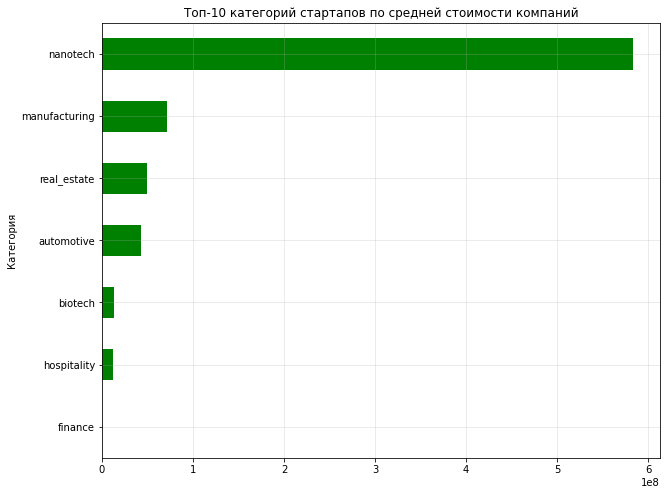

In [119]:
# Визуализируем при помощи линейчатой диаграммы:
plt.figure(figsize=(10,8))

top_7_mean.sort_values(ascending=True).plot(
    kind='barh',
    title='Топ-10 категорий стартапов по средней стоимости компаний',
    legend=False,
    rot=0,
    xlabel='Категория',
    ylabel='Средняя стоимость стартапа',
    color='green'
)

plt.grid(True, alpha=0.3)

In [120]:
# Найдем топ-10 компаний с наибольшим разбросом цен за стартап
top_10_std = startups_info.groupby('category_code')['price_amount'].std().sort_values(ascending=False).head(7)
display(top_10_std)

category_code
enterprise          1.280882e+11
public_relations    4.086811e+09
real_estate         2.505123e+09
automotive          2.297758e+09
biotech             1.540374e+09
health              1.249084e+09
other               1.086832e+09
Name: price_amount, dtype: float64

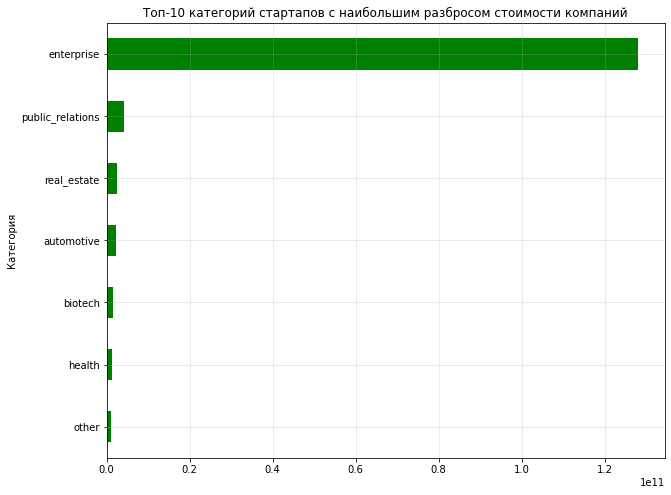

In [121]:
# Визуализируем при помощи линейчатой диаграммы:
plt.figure(figsize=(10,8))

top_10_std.sort_values(ascending=True).plot(
    kind='barh',
    title='Топ-10 категорий стартапов с наибольшим разбросом стоимости компаний',
    legend=False,
    rot=0,
    xlabel='Категория',
    ylabel='Разброс стоимости компаний',
    color='green'
)

plt.grid(True, alpha=0.3)


### Сколько раундов продержится стартап перед покупкой

- Необходимо проанализировать и определить типичное значение количества раундов для каждого возможного статуса стартапа.

In [122]:
# Объединим датасеты companies и funding_rounds
companies_rounds = pd.merge(target_companies, funding_rounds, how='inner', left_on='company_id', right_on='funded_company_id')
companies_rounds.info()
companies_rounds.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15949 entries, 0 to 15948
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company_id           15949 non-null  int32         
 1   name                 15949 non-null  object        
 2   category_code        14557 non-null  category      
 3   status               15949 non-null  category      
 4   founded_at           11544 non-null  datetime64[ns]
 5   closed_at            1415 non-null   datetime64[ns]
 6   domain               14452 non-null  object        
 7   network_username     7383 non-null   object        
 8   country_code         14051 non-null  category      
 9   investment_rounds    15949 non-null  int16         
 10  funding_rounds       15949 non-null  int8          
 11  funding_total        15949 non-null  float64       
 12  milestones           15949 non-null  int8          
 13  funding_total_m      15949 non-

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,funding_total_m,funding_round_id,funded_company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0,...,39.75,1,1,2006-12-01,series-b,8500000.0,0.0,2.0,False,False
1,10,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0,...,0.00,10,10,2006-06-01,angel,12000.0,0.0,1.0,False,True
2,100,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0,...,0.00,100,100,2008-06-02,series-a,1000000.0,0.0,4.0,True,True
3,1001,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0,...,5.00,1001,1001,2006-01-01,series-a,35391000.0,0.0,1.0,False,True
4,10014,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0,...,0.00,10014,10014,2009-11-20,angel,100000.0,0.0,0.0,True,False


In [123]:
# Исключим нулевые значения из выборки:
companies_rounds = companies_rounds[companies_rounds['funding_rounds']> 0]

In [124]:
# Изучем описательную статистику
companies_rounds['funding_rounds'].describe()

count    12011.000000
mean         1.991924
std          1.492703
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         14.000000
Name: funding_rounds, dtype: float64

In [125]:
# Сруппируем средние значения раундов финансирования по статусам
statuses_avg_rounds = companies_rounds.groupby(['status'])['funding_rounds'].mean().sort_values(ascending=False)
display(statuses_avg_rounds)

status
ipo          2.828383
operating    2.047727
acquired     2.012358
closed       1.442599
Name: funding_rounds, dtype: float64

У большей части (75%) компаний количество раундов финансирования не превышает 3, из-за чего разница в средних значениях раундов финансирования для компаний разных статусов невелика.

Наибольшее среднее число раундов (2,83) - у компаний на стадии ipo (первичное публичное размещение акций компании).
Наименьшее среднее количество раундов финансирования (1,44) - у компаний на стадии operating (действующие).

Визуализируем при помощи столбчатого графика:

<Axes: title={'center': 'Среднее количество рандов финансирования для компаний, имеющих разный статус'}, xlabel='Статус компании', ylabel='Среднее кол-во раундов финансирования'>

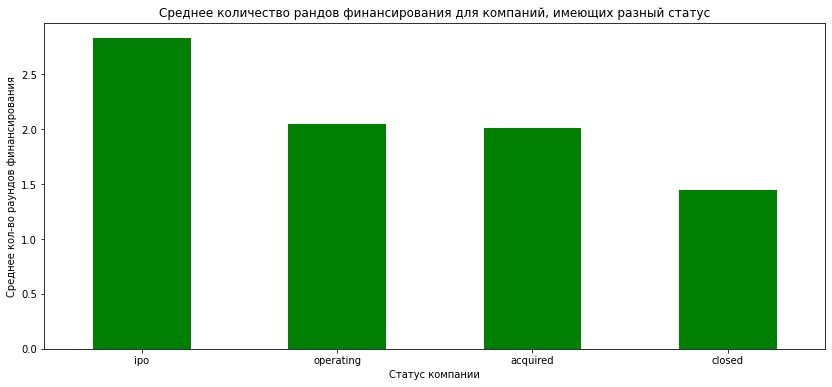

In [126]:
# Построим столбчатую диаграмму
plt.figure(figsize=(14,6))

statuses_avg_rounds.plot(
    kind='bar',
    title='Среднее количество рандов финансирования для компаний, имеющих разный статус',
    legend=False,
    rot=0,
    xlabel='Статус компании',
    ylabel='Среднее кол-во раундов финансирования',
    color='green'
)


## Итоговый вывод и рекомендации <a class="anchor" id="fourth-bullet"></a>


В рамках исследования была проведена первичная обработка данных:
* Изменение типов данных на наиболее подходящие
* Поиск и удаление дубликатов
* Даны рекомендации по обработке пропусков в каждом конкретном столбце.

На этапе предварительного исследования были выполнены следующие задачи: 
* Проанализирована информация о раундах финансирования (типичный объем финанасирования и кол-во раундов) по годам (1999-2013 гг.), а также создан отдельный срез только по 2013 году.
* Была произведена оценка доли сотрудников со сведениями об образовании в разрезе размеров компаний. Подсчеты выполнены по двум методикам: с использованием данных об образовании из датасета `education` и датасета `degrees`.
* Проанализированы выбросы в данных, содержащих размеры финансирования компаний.
* Проблемный датасет `companies_and_rounds` был разбит на два, благодаря чему удалось избавиться от большого числа дубликаов и выбросов.

На этапе исследовательского анализа данных получены следующие выводы:

1. В качестве основы для анализа ообраны только те компании, у которых указаны значения funding_rounds или investment_rounds больше нуля, или те, у которых в колонке status указано acquired. В результирующей таблице оказалось 40,7 тыс. компаний. Таким образом, мы отобрали для работы те стартапы, которые получали финансирование или были куплены.


2. Произведен анализ выбросов для значений общего размера финансирования:
* Распределение данных о размерах финансирования компаний имеет выраженную правостороннюю ассиметрию.
* Минимальное значение - 0 у.е., а максимальное - 5,7 млрд. у.е. Такие высокие значения не являются ошибкой - согласно источнику bloomberg.com, одним из самых дорогих стартапов является компания Uber, привлекшая 20 млрд. долларов за все время работы.
* Типичный размер общего финансирования (по медиане) - 2,56 млн. у.е., при этом третий квартиль равен 11 млн. у.е.
* Наиболее высокие значения (95-1 и 99-й перцентили) - 58,45 млн. у.е. и 175,1 у.е.
* Ввиду сильного разброва в данных, типичные значения могут очень сильно зависеть от сферы стартапа, страны, года (для ретро данных) и прочих факторов. Также для анализа типичных значений выбросы стоит исключать, потому что они вызывают сильное смещение среднего значения в большую сторону.

3.1 Всего в датасете оказалось 1615 компаний, купленных за 0 или 1 у.е. Важно отметить, что это популярное явление, не заависящее от каких-либо факторов: такие компании встречаются в разных странах, сферы их деятельности разнообразны, и способы расчета по таким сделкам тоже разные.

Причины сделок за 0 или 1 у.е. могут быть следующими:
* Юридическая формальность: в договоре при оформлении передачи прав собственности стоимость компании может быть записана как 0 или 1 доллар, при этом настоящая цена сделки может быть прописана в договоре отдельно в виде нескольких платежей.
* "Спасение" компании: при угозе банкротства компании собственник может продать компанию за символическую сумму лицу, заинтересованному в продолжении ведения этого бизнеса.
* Передача прав на интеллектуальную собственность: продажа юридического лица, которому принадлежат эти права за символическую сумму — эффективный способ их передачи.
* Реструктуризация (характерна для групп компаний): Продажа за доллар может означать передачу юрлица дочерней компании.
* Приостановка деятельности компании на территории определенной страны (характерно для крупных международных компаний): такие случаи были зафиксированы в России во время массового ухода компаний в 2022 г.

3.2 Верхняя граница выбросов для размеров финансирования - 35,75 млн. у.е.что соответствует 90,9 перцентилю. Нижнюю границу выбросов посчитать невозможно, т.к. минимальное значение - 0, и оно не является выбросом. Как говорилось ранее, разброс данных велик, и это стоит учитывать при анализе.

4. Составлен топ-7 категорий стартапов (по сфере деятельности) с типично высокими ценами и наибольшим разбросом цен за стартап. Самый высокий размер финансирования по медианы имеют старапы категории nanotech - такие стартапы действительно требуют крупных инвестиций для реализации сложных технологических идей. Самая большая вариабельность данных -  у стартапов категории enterprise.

5. Проведен анализ типочного кол-ва раундов финансирования для стартапов, имеющих разный статус:
* У большей части (75%) компаний количество раундов финансирования не превышает 3, из-за чего разница в средних значениях раундов финансирования для компаний разных статусов невелика.
* Наибольшее среднее число раундов (2,83) - у компаний на стадии ipo (первичное публичное размещение акций компании). Наименьшее среднее количество раундов финансирования (1,44) - у компаний на стадии operating (действующие).